

---


### **Name: Titus M. Makumbe**

### Student Number: ST10467199

### Module Code: PDAN8411

### Date: 21 April 2026

### Submission: Formative 1

---








## Part 1: Justification of Dataset Suitability for Linear Regression

**Dataset Overview**

The Medical Cost Personal dataset contains 1,338 complete observations with seven columns (Choi, 2026). Age is a datatype integer ranging from 18 to 64 years, with a mean of 39,2. Sex is a string datatype, with 51% male and 49% female. BMI is a decimal datatype ranging from 16 to 53,1, with a mean of 30.7. The number of children is an integer datatype ranging from 0 to 5, with a mean of 1,09. Smokers are a binary datatype with values of “yes” and “no”. The region is a string datatype, with four US areas (27% southeast, 24% southwest, and 49% others). The target variable “charges” is a decimal datatype ranging from 1,120 to 63,800, with a mean of 13,300. The column “Charges” is continuous and positive, making it suitable for linear regression, as it assumes that there is a linear relationship between the “charge” (Y) and the predictor variables (Age, Sex, BMI, Number of Children, Smokers and Region) (James et al., 2023).  Thus, linear regression is also interpreted, producing dollar impacts for each customer variable.


**Suitability Checklist for Linear Regression**

The evaluation of the dataset against the key assumptions of linear regression, based solely on the dataset description, leads to the following conclusions.

1.	**Linear relationship between features and target:**
Based on the dataset structure, the predictors age and BMI are continuous numerical variables, and “charges” is a continuous target. There is no theoretical reason to expect a non-linear relationship between age and medical charges, as healthcare costs typically increase with age. For BMI, medical costs generally increase with higher BMI values, suggesting a positive relationship. The children variable (0-5) may have a non-linear pattern, but linear regression can still be applied with appropriate preprocessing. The categorical variables – sex, smoker and region will be encoded numerically, and linear regression can capture mean differences between categories (James et al., 2023). Therefore, the linearity assumption is likely and will be verified during EDA.

2.	**No perfect multicollinearity:**
Based on the dataset structure, there is no logical reason why age would be perfectly correlated with sex, BMI, children, smoker, or region. Age and BMI may have some correlation, as older people may have higher BMI, but perfect correlation is impossible as both variables have varying values. Smoker status is independent of age and sex based on the dataset description. Region is geographically independent of other variables. Thus, the multicollinearity assumption is likely satisfied for linear regression (Molnar, 2025).

3.	**Independence of errors:**
I am also assuming that the data was collected from different individuals at a single point in time, as there is no time series component that would cause errors to be correlated across observations. Each row represents a unique customer. Therefore, the independence of errors assumption is inherently satisfied for this dataset (Molnar, 2025).

4.	**Homoscedasticity:**
Without the EDA, it will not be possible, based on the dataset description alone, to determine if homoscedasticity holds. Medical cost data usually have higher costs with more variability. This assumption will need to be checked during EDA using residuals-versus-fitted plots. The assumption is unknown and will be verified after model fitting (Molnar, 2025).


**Data Quality Assessment**

The dataset has no missing values across any column, as (Choi, 2026) mentioned that there was some data cleaning to the dataset. In addition, there are no mismatched data types or corrupted entries. The age distribution focuses on working-age adults (18-64 years). Sex is balanced (51% male, 49% female) (Choi, 2026).

**Common Pitfalls Addressed**

Several pitfalls that will need to be addressed.

1.	**Encoding variables:**
When we encode the variable region, which has four categories, we will obtain four variables that add up to one, which will cause perfect multicollinearity (Molnar, 2025). This will need to be addressed.
2.	**Outliers:**
Based on the dataset, charges range from 1,120 to 63,800, with a mean of 13,300, suggesting potential outliers in the upper tail. Outliers will be detected using the IQR method to improve accuracy (Molnar, 2025).
3.	**Heteroscedasticity:**
Healthcare cost data often has non-constant variance. If detected via residual plots, a logarithmic transformation of charges will be applied (Molnar, 2025).
4.	**Non-linearity:**
The variable “number of children” that ranges from 0 to 5 may have a non-linear relationship with charges. If detected via scatter plots, logarithmic transformations might be required (James et al., 2013).
5.	**Multicollinearity:**
Variables like age and BMI may be correlated. The VIF will be calculated, and if values exceed 5, one predictor will be removed, or regularisation will be used (Molnar, 2025).
6.	**Data leakage:**
The dataset will need preprocessing steps to be applied (scaling, encoding, and outlier capping), which can lead to data leakage (Molnar, 2025).
7.	**Overfitting:**
With 1,338 observations and 7 predictors, overfitting is unlikely but will be prevented using train/validation and test splits (Molnar, 2025).


**Conclusion on Suitability**

Based on the dataset description, the dataset is provisionally suitable for linear regression. The target “charges” is continuous and positive (Molnar, 2025). The data have no missing values, and multicollinearity is unlikely. The sample size of 1,338 is also large, providing robustness for linear regression.

However, EDA is needed to verify linearity, detect outliers (likely in charges), and check for heteroscedasticity. These can be addressed with log transformation and outlier capping (Molnar, 2025). Linear regression is interpretable, which the client needs for a sliding scale of charges (Molnar, 2025).


## Part 2: Planning Analysis

This section outlines the planned analysis steps before conducting the EDA with assumptions based solely on the dataset.

#### **Exploratory Data Analysis**

For the EDA, below will be the steps I will follow:

**Step 1: Load Data and Initial Inspection**

To import the insurance.csv file into Python, verify the data dimensions (which should be 1,338 rows and 7 columns), check the column names and data types, and preview the initial five rows using df.head() (McKinney, 2022).

**Step 2: Check Data Quality**

I would then use df.isnull().sum() to evaluate missing values. Use df.duplicated().sum() to check duplicates. Standardise values that are inconsistent in categories (McKinney, 2022).

**Step 3: Generate Summary Statistics**

I would then use df.describe() to determine skewness for charges and produce descriptive statistics for age, BMI, children, and charges. Create frequency counts by region, smoker, and sex (McKinney, 2022).

**Step 4: Create Univariate Visualisations**

After that, plot the histograms for age, BMI, number of children, and charges. To find outliers, make boxplots for age, BMI, and charges (McKinney, 2022).

**Step 5: Create Bivariate Visualisations (Test Linearity)**

Make scatter plots with regression lines showing the relationship between age and charges, BMI and charges, and children and charges. Create boxplots to display the “charges” categorised by region, smoking status, and sex (McKinney, 2022).

**Step 6: Conduct Statistical Tests**

Next, perform t-tests for the variables smokers and sex. Do a region-specific ANOVA. P-values of less than 0.05 are deemed significant (McKinney, 2022).

**Step 7: Detect Outliers**
Next, apply the IQR approach to charges while keeping in mind that certain extreme values, such as BMI, may have clinical validity (McKinney, 2022).

**Step 8: Perform Correlation Analysis**

Next, encode categorical variables (region one-hot with drop_first=True; sex, smoker as binary). Create a heatmap and correlation matrix. Determine VIF (McKinney, 2022).

**Step 9: Make Data Transformation Decisions**

Next, if the charges are non-linear, use the log transformation. McKinney (2022).

**Step 10: Document EDA Findings**

Lastly, document data quality, linearity, significance of predictors, multicollinearity, skewness, outliers, and final preprocessing plan (McKinney, 2022).

#### **Feature Selection**

We shall encode categorical variables. I will then use the t-test to evaluate each individual coefficient, followed by backward elimination of each individual coefficient using p < 0.05, which offers a 95% confidence level that a predictor actually influences charges (Bruce, Bruce, and Gedeck, 2020). In order to eliminate multicollinearity, correlated predictors will also be removed using VIF scores.


#### **Train Model**

A linear regression model will be trained using the LinearRegression() class from scikit-learn (Lavin, 2022). The model will be trained on the training set (80% of data). The target variable charges will be log-transformed if skewness is detected during EDA to improve model performance (Lavin, 2022). Features will be standardised using StandardScaler to ensure all predictors are on the same scale(Lavin, 2022). The model will be trained using model.fit(X_train, y_train) and predictions will be made using model.predict(X_test).


#### **Interpret and Evaluate Model**

The coefficients from the trained model will be extracted using model.coef_ and the intercept using model.intercept_ after the linear regression model has been trained using LinearRegression() from scikit-learn (Lavin, 2022). With all other predictors held constant, these coefficients will show how the target variable (charges) changes as each predictor changes by one unit. The coefficients will be translated into monetary implications for business understanding. The client will receive a clear sliding scale formula from a coefficient table that displays the impact of each predictor on charges (e.g., smoker +$X, each  year  of  the age +$X) (James et al., 2023).


#### **The final Report**

The final report will include:

Executive Summary – Which will be a  non-technical overview of key findings and model performance.

Data Preparation – Which will be the documentation of EDA outcomes, data quality issues addressed (missing values, duplicates, outliers), and preprocessing decisions (encoding, log transformation, outlier capping). Basic data information will be presented, including 1,338 observations, 7 features (age, sex, BMI, children, smoker, region), and the target variable charges (McKinney, 2022).

Model Training – The description of the linear regression model using LinearRegression() from scikit-learn, including the 80/20 train-test split, log transformation of charges if skewed, and standardisation using StandardScaler (Lavin, 2022).

Visualisations – Including scatter plots (age vs charges coloured by smoker status), boxplots (charges by smoking status), and distribution of charges before and after log transformation (Lavin, 2022).

Model Interpretation – The presentation of a coefficient table showing the effect of each predictor on charges (e.g., smoker +$X,each year of Age +$X), providing the client with a clear sliding scale formula (James et al., 2013).

Limitations – Provide any limitations found in medical health dataset (James et al., 2023).

Recommendations – Provide any actionable steps from the interpretation of the model.


 ## Part 3: Conduct Analysis

This section presents the actual analysis conducted following the plan outlined in Part 2.

### 3.1 Import dataset and Required Libraries

In [2]:
# ============================================================
# STEP 1a: Import the dataset
# Purpose: Load the dataset for the EDA
# Reference: (Choi, 2026)
# ============================================================

!kaggle datasets download mirichoi0218/insurance

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
100% 16.0k/16.0k [00:00<00:00, 22.6MB/s]



In [3]:
# ============================================================
# STEP 1b: Import the dataset
# Purpose: Unzip the dataset for the EDA
# Reference: (Choi, 2026)
# ============================================================

import zipfile
with zipfile.ZipFile('insurance.zip', 'r') as zip_ref:
    zip_ref.extractall('./') # Unzipping the dataset contents into the current directory


In [5]:
# ============================================================
# STEP 1c: Import required libraries
# Purpose: Load all necessary packages for data manipulation,
# visualisation, statistical analysis, and machine learning
# Reference: (McKinney, 2022)
# ============================================================

import pandas as pd # Data manipulation and analysis
import numpy as np # Numerical operations
import matplotlib.pyplot as plt # Data visualisation
import seaborn as sns # Statistical data visualisation
from scipy import stats # Statistical functions
from sklearn.model_selection import train_test_split    # Train-test split for model evaluation
from sklearn.preprocessing import StandardScaler    # Feature scaling for machine learning models
from sklearn.linear_model import LinearRegression   # Linear regression model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score   # Evaluation metrics for regression models
import statsmodels.api as sm    # Statistical models and tests
from statsmodels.stats.outliers_influence import variance_inflation_factor      # Variance Inflation Factor for multicollinearity assessment

# Setting visualisation style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300

### 3.2 Exploratory Data Analysis (EDA)

In [6]:
# ============================================================
# STEP 2: Load Data and Initial Inspection
# Purpose: Import the dataset into a dataframe and understand its basic structure
# Reference: (McKinney, 2022)
# ============================================================

df = pd.read_csv('insurance.csv') # Load the insurance dataset

# Display basic information about the dataset
print("=== BASIC DATA INSPECTION ===\n")
print(f"Shape of dataset: {df.shape}\n")  # Expected: 1338 rows, 7 columns
print(f"Column names: {df.columns.tolist()}\n")
print(f"Data types:\n{df.dtypes}")

# Preview first 5 rows
print("\n=== FIRST 5 ROWS ===")
print(df.head())

# Preview last 5 rows
print("\n=== LAST 5 ROWS ===")
print(df.tail())

=== BASIC DATA INSPECTION ===

Shape of dataset: (1338, 7)

Column names: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

=== FIRST 5 ROWS ===
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

=== LAST 5 ROWS ===
      age     sex    bmi  children smoker     region     charges
1333   50    male  30.97         3     no  northwest  10600.5483
1334   18  female  31.92         0     no  northeast   2205.9808
1335   18  female  36.85         0     no  southeast   1629.8335
1336   

In [7]:
# ============================================================
# STEP 3: Check Data Quality
# Purpose: Identify missing values, duplicates, and inconsistencies
# Reference: (McKinney, 2022)
# ============================================================

print("\n=== DATA QUALITY ASSESSMENT ===\n")

# Check for missing values in each column
missing_values = df.isnull().sum()
print(f"Missing values per column:\n{missing_values}")




=== DATA QUALITY ASSESSMENT ===

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


No missing values detected for all columns.

In [8]:
# View the data objects for the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
# Check unique values in categorical columns to identify inconsistencies for dtype = object
print("\nUnique values in categorical columns:")
print(f"sex: {df['sex'].unique()}")
print(f"smoker: {df['smoker'].unique()}")
print(f"region: {df['region'].unique()}")


Unique values in categorical columns:
sex: ['female' 'male']
smoker: ['yes' 'no']
region: ['southwest' 'southeast' 'northwest' 'northeast']


In [10]:
# Fill in age if we had missing values
df['age'].fillna(df['age'].mean(), inplace=True)

# Fill in bmi if we had missing values
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

/tmp/ipykernel_7458/1223048779.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)
/tmp/ipykernel_7458/1223048779.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [11]:
# Final check for missing values in each column after filling values
missing_values = df.isnull().sum()
print(f"Missing values per column:\n{missing_values}\n")

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64



In [12]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 1


In [13]:
# Show duplicate rows if any
if duplicate_count > 0:
    print("\n=== DUPLICATE ROWS ===")
    display(df[df.duplicated(keep=False)])
else:
    print("\nNo duplicate rows found.")


=== DUPLICATE ROWS ===


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [14]:
# Remove duplicate if found
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")

Duplicates removed. New shape: (1337, 7)


In [15]:
# Show duplicate rows if any
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    print("\n=== DUPLICATE ROWS ===")
    display(df[df.duplicated(keep=False)])
else:
    print("\nNo duplicate rows found.")


No duplicate rows found.


In [16]:
# ============================================================
# STEP 4: Generate Summary Statistics
# Purpose: Understand the distribution shape
# Reference: (McKinney, 2022)
# ============================================================

print("\n=== SUMMARY STATISTICS ===")

# Descriptive statistics for numerical columns
numeric_cols = ['age', 'bmi', 'children', 'charges']
summary_stats = df[numeric_cols].describe()
print(summary_stats)

# Calculate skewness to assess distribution symmetry
# Skewness > 1 indicates significant right skew
print("\n=== SKEWNESS AND KURTOSIS ===")
for col in numeric_cols:
    skew_val = df[col].skew()
    kurt_val = df[col].kurtosis()
    print(f"{col}: Skewness = {skew_val:.3f}, Kurtosis = {kurt_val:.3f}")



=== SUMMARY STATISTICS ===
               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010

=== SKEWNESS AND KURTOSIS ===
age: Skewness = 0.055, Kurtosis = -1.244
bmi: Skewness = 0.284, Kurtosis = -0.053
children: Skewness = 0.937, Kurtosis = 0.201
charges: Skewness = 1.515, Kurtosis = 1.604


In [17]:
# Frequency counts for categorical variables
print("\n=== CATEGORICAL VARIABLE FREQUENCIES ===")
print(f"Sex distribution:\n{df['sex'].value_counts()}")
print(f"\nSmoker distribution:\n{df['smoker'].value_counts()}")
print(f"\nRegion distribution:\n{df['region'].value_counts()}")


=== CATEGORICAL VARIABLE FREQUENCIES ===
Sex distribution:
sex
male      675
female    662
Name: count, dtype: int64

Smoker distribution:
smoker
no     1063
yes     274
Name: count, dtype: int64

Region distribution:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


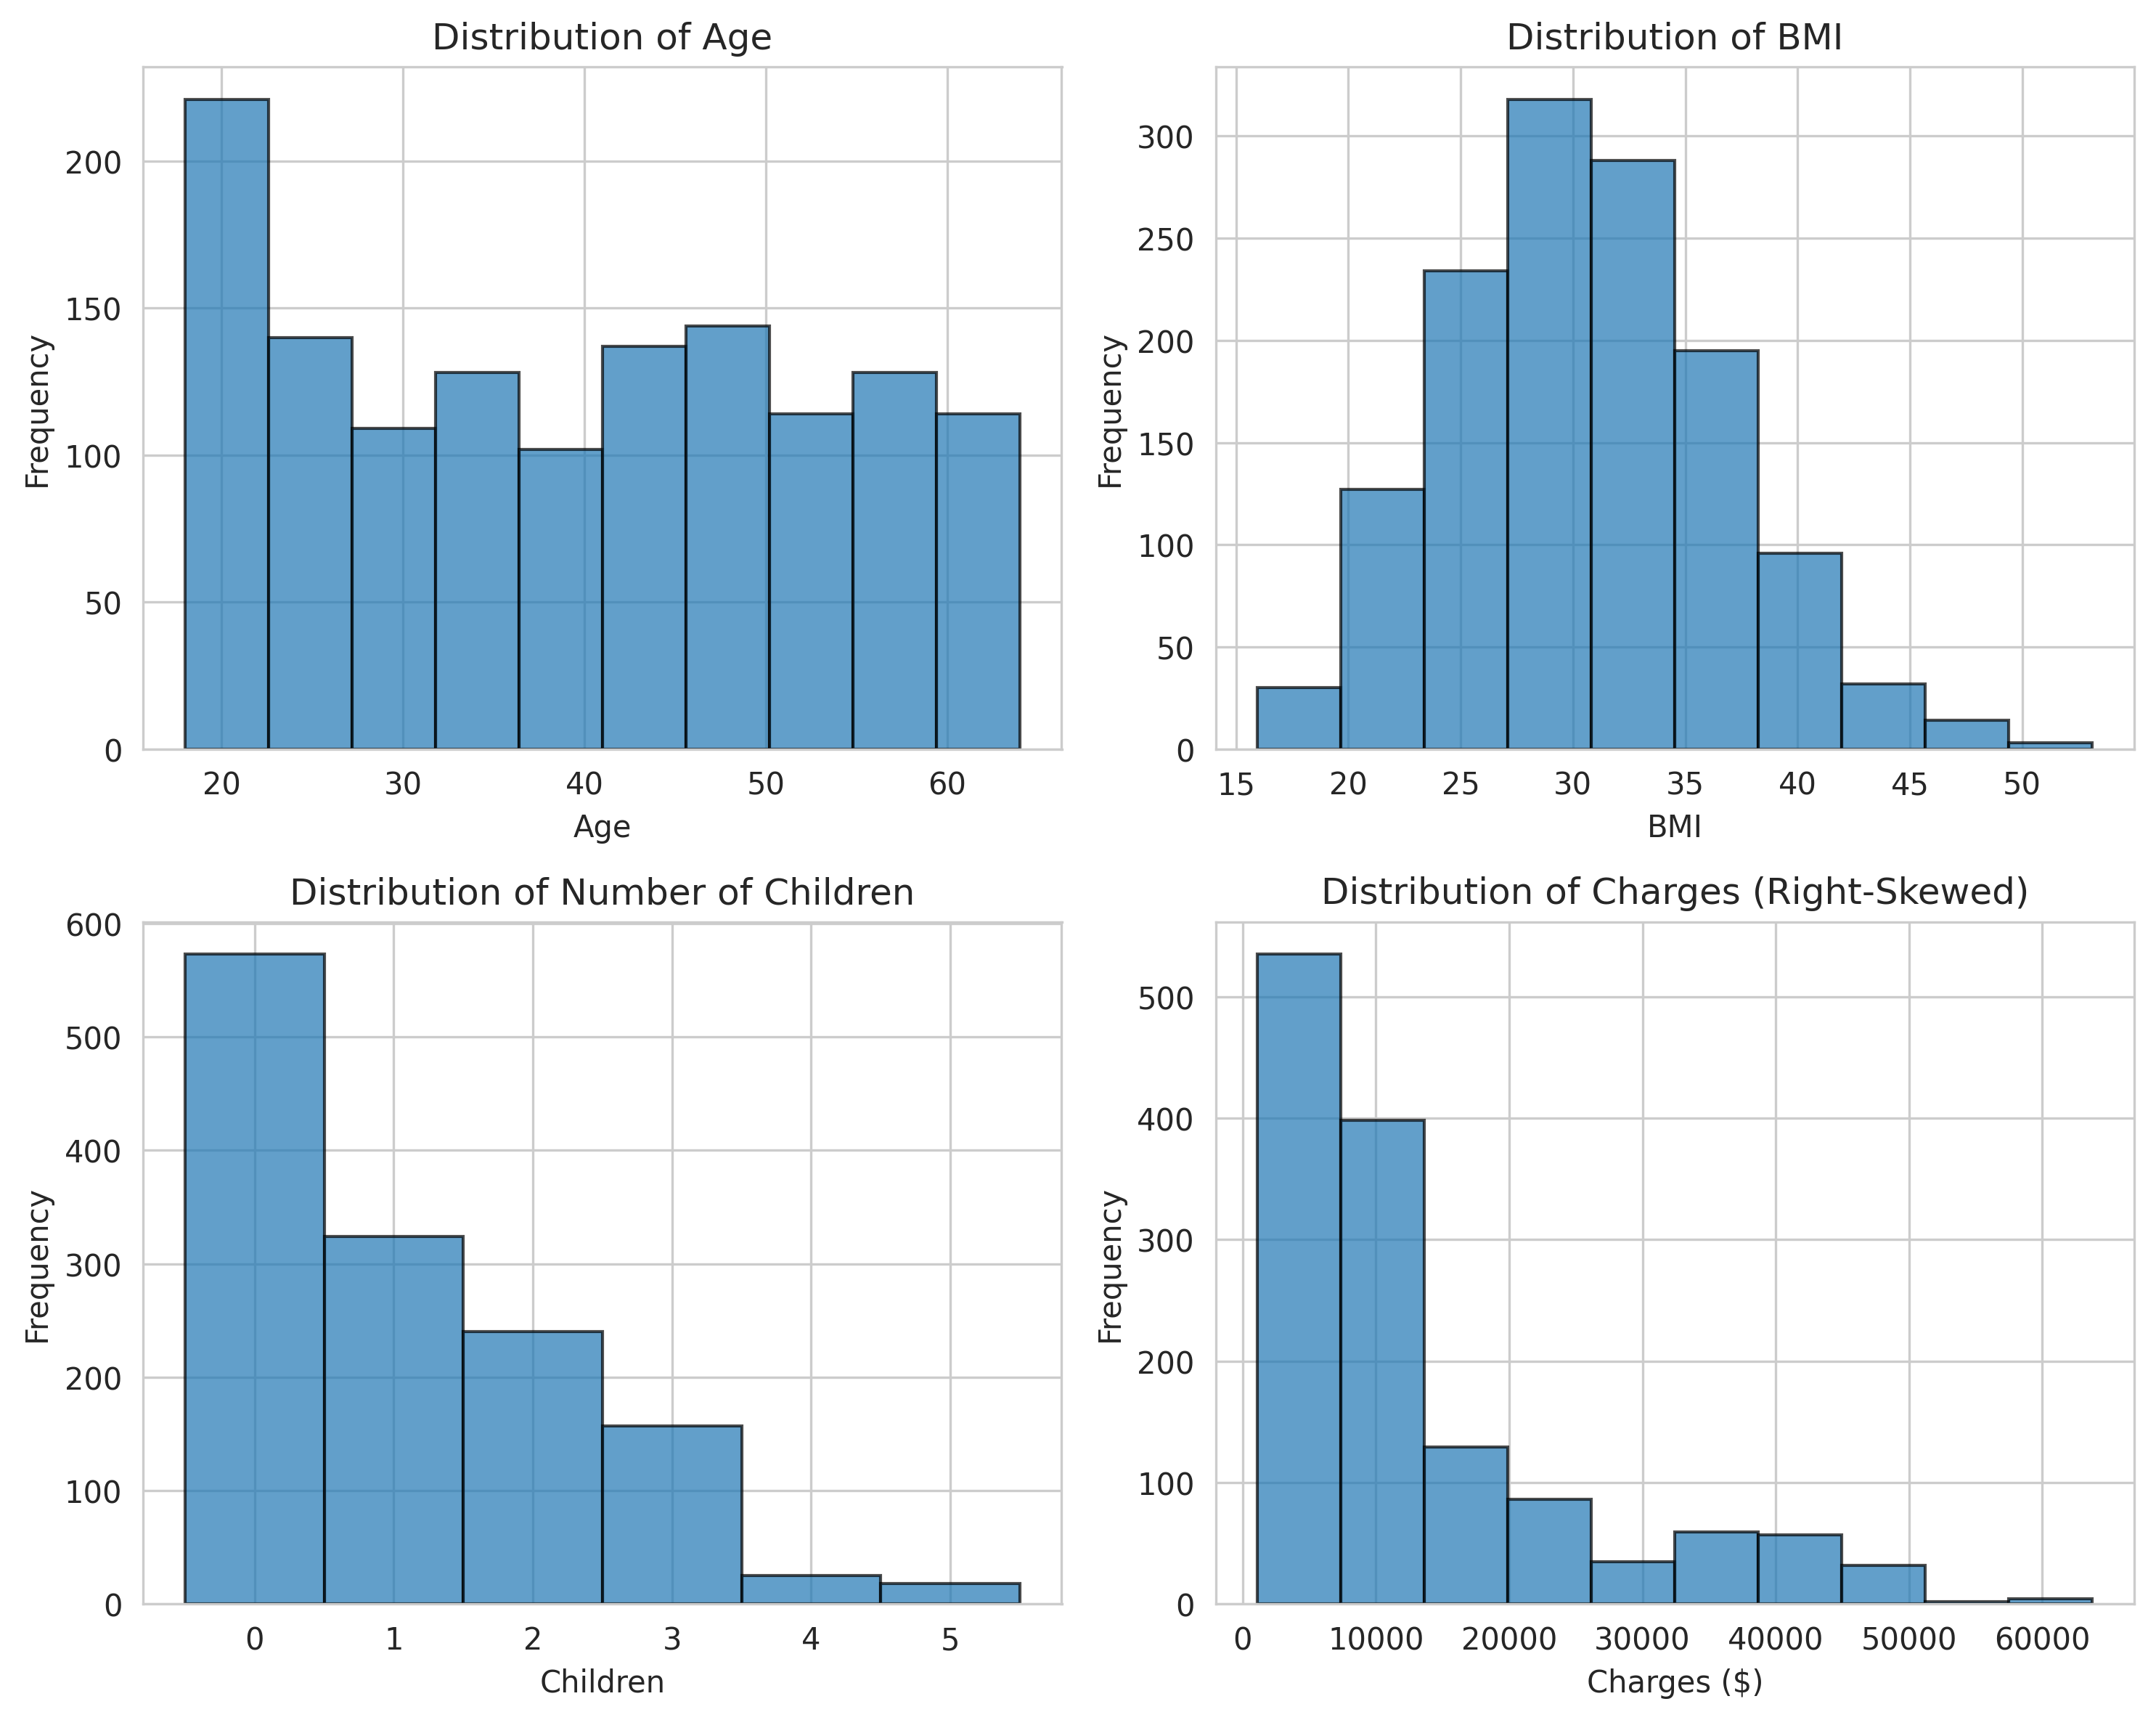

In [18]:
# ============================================================
# STEP 5: Create Univariate Visualisations
# Purpose: Visualise individual variable distributions and identify outliers
# Reference: (McKinney, 2022)
# ============================================================

# Create a figure with 2 rows and 2 columns for histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Histogram of Age
axes[0, 0].hist(df['age'], bins=10, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Age')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

# Histogram of BMI
axes[0, 1].hist(df['bmi'], bins=10, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution of BMI')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Frequency')

# Histogram of Children
axes[1, 0].hist(df['children'], bins=range(7), edgecolor='black', alpha=0.7, align='left')
axes[1, 0].set_title('Distribution of Number of Children')
axes[1, 0].set_xlabel('Children')
axes[1, 0].set_ylabel('Frequency')

# Histogram of Charges
axes[1, 1].hist(df['charges'], bins=10, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribution of Charges (Right-Skewed)')
axes[1, 1].set_xlabel('Charges ($)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('univariate_visualisations.png', dpi=300)
plt.show()


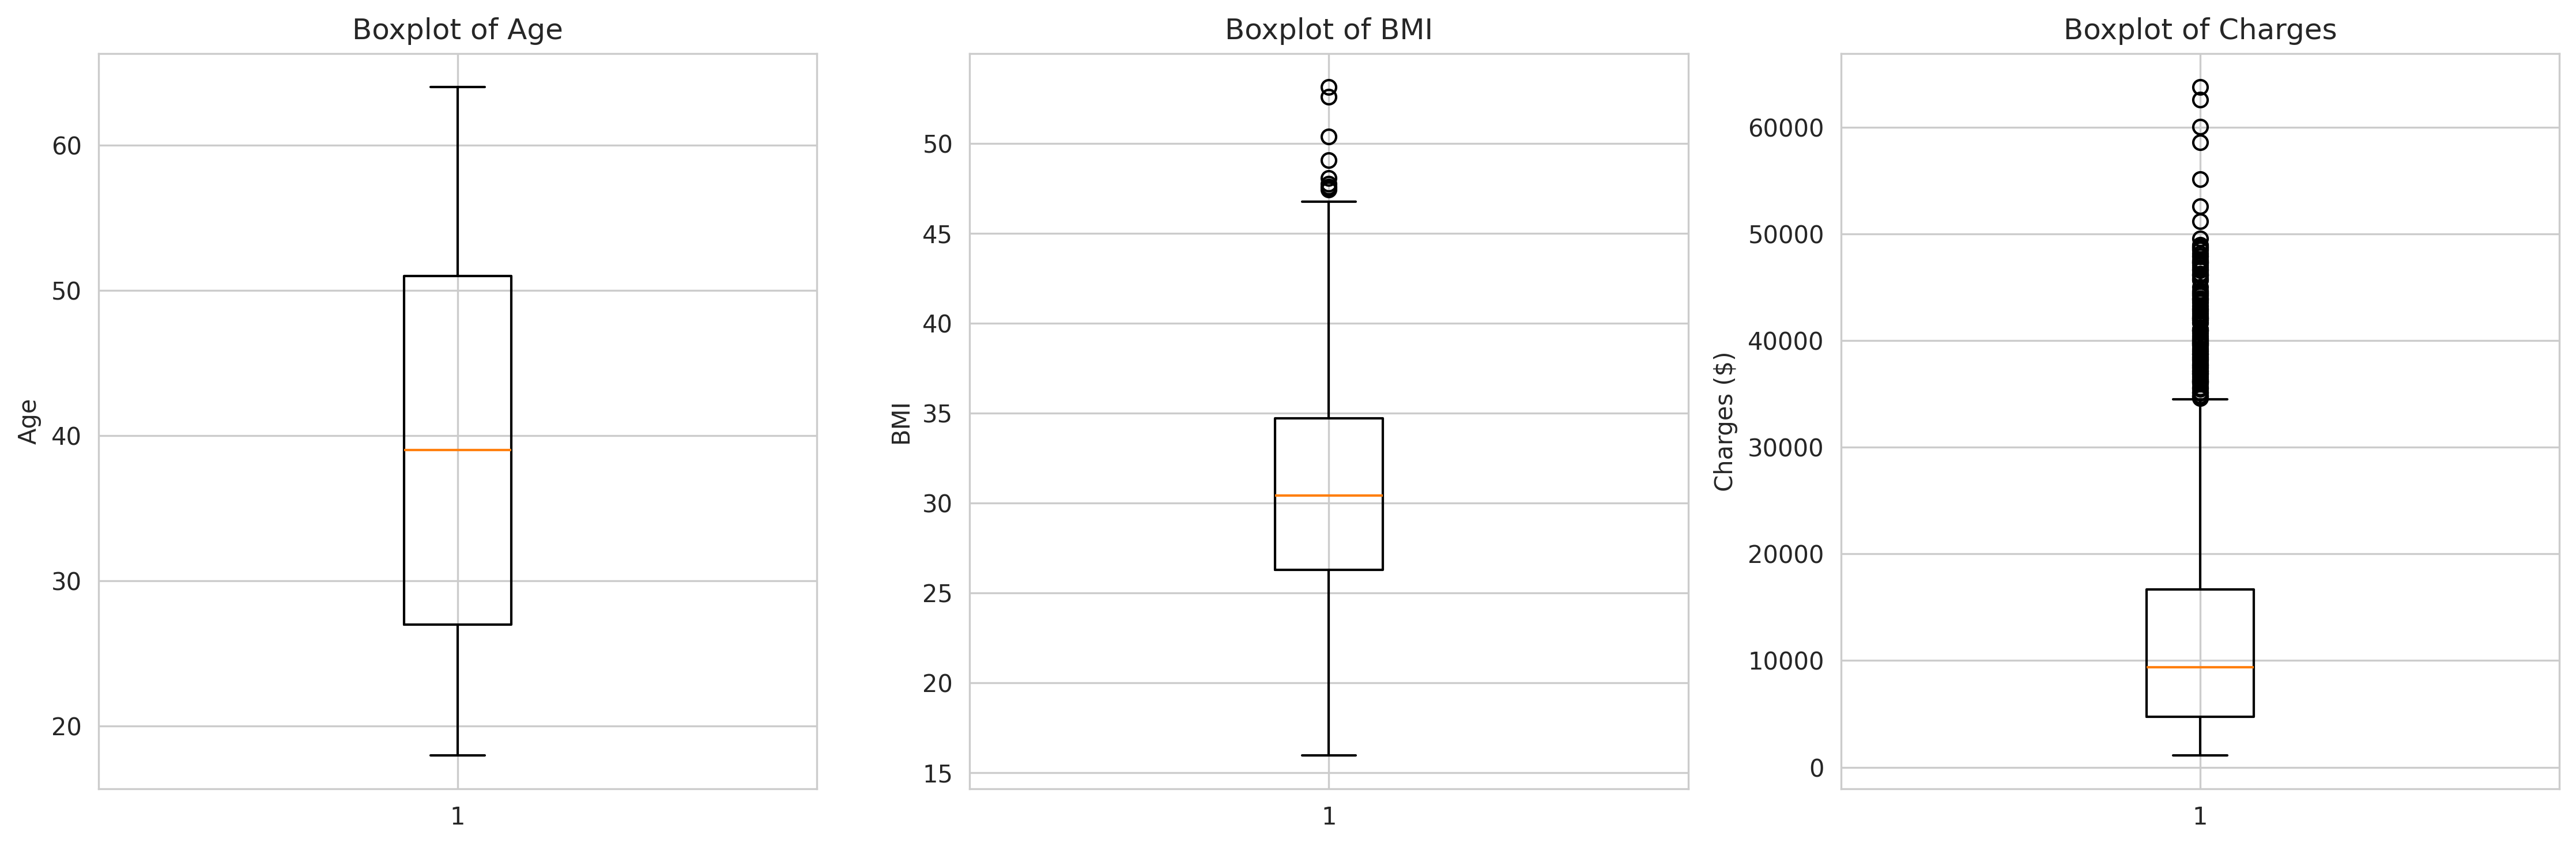

In [19]:

# Boxplots for outlier detection
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boxplot for Age
axes[0].boxplot(df['age'])
axes[0].set_title('Boxplot of Age')
axes[0].set_ylabel('Age')

# Boxplot for BMI
axes[1].boxplot(df['bmi'])
axes[1].set_title('Boxplot of BMI')
axes[1].set_ylabel('BMI')

# Boxplot for Charges
axes[2].boxplot(df['charges'])
axes[2].set_title('Boxplot of Charges')
axes[2].set_ylabel('Charges ($)')

plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=300)
plt.show()

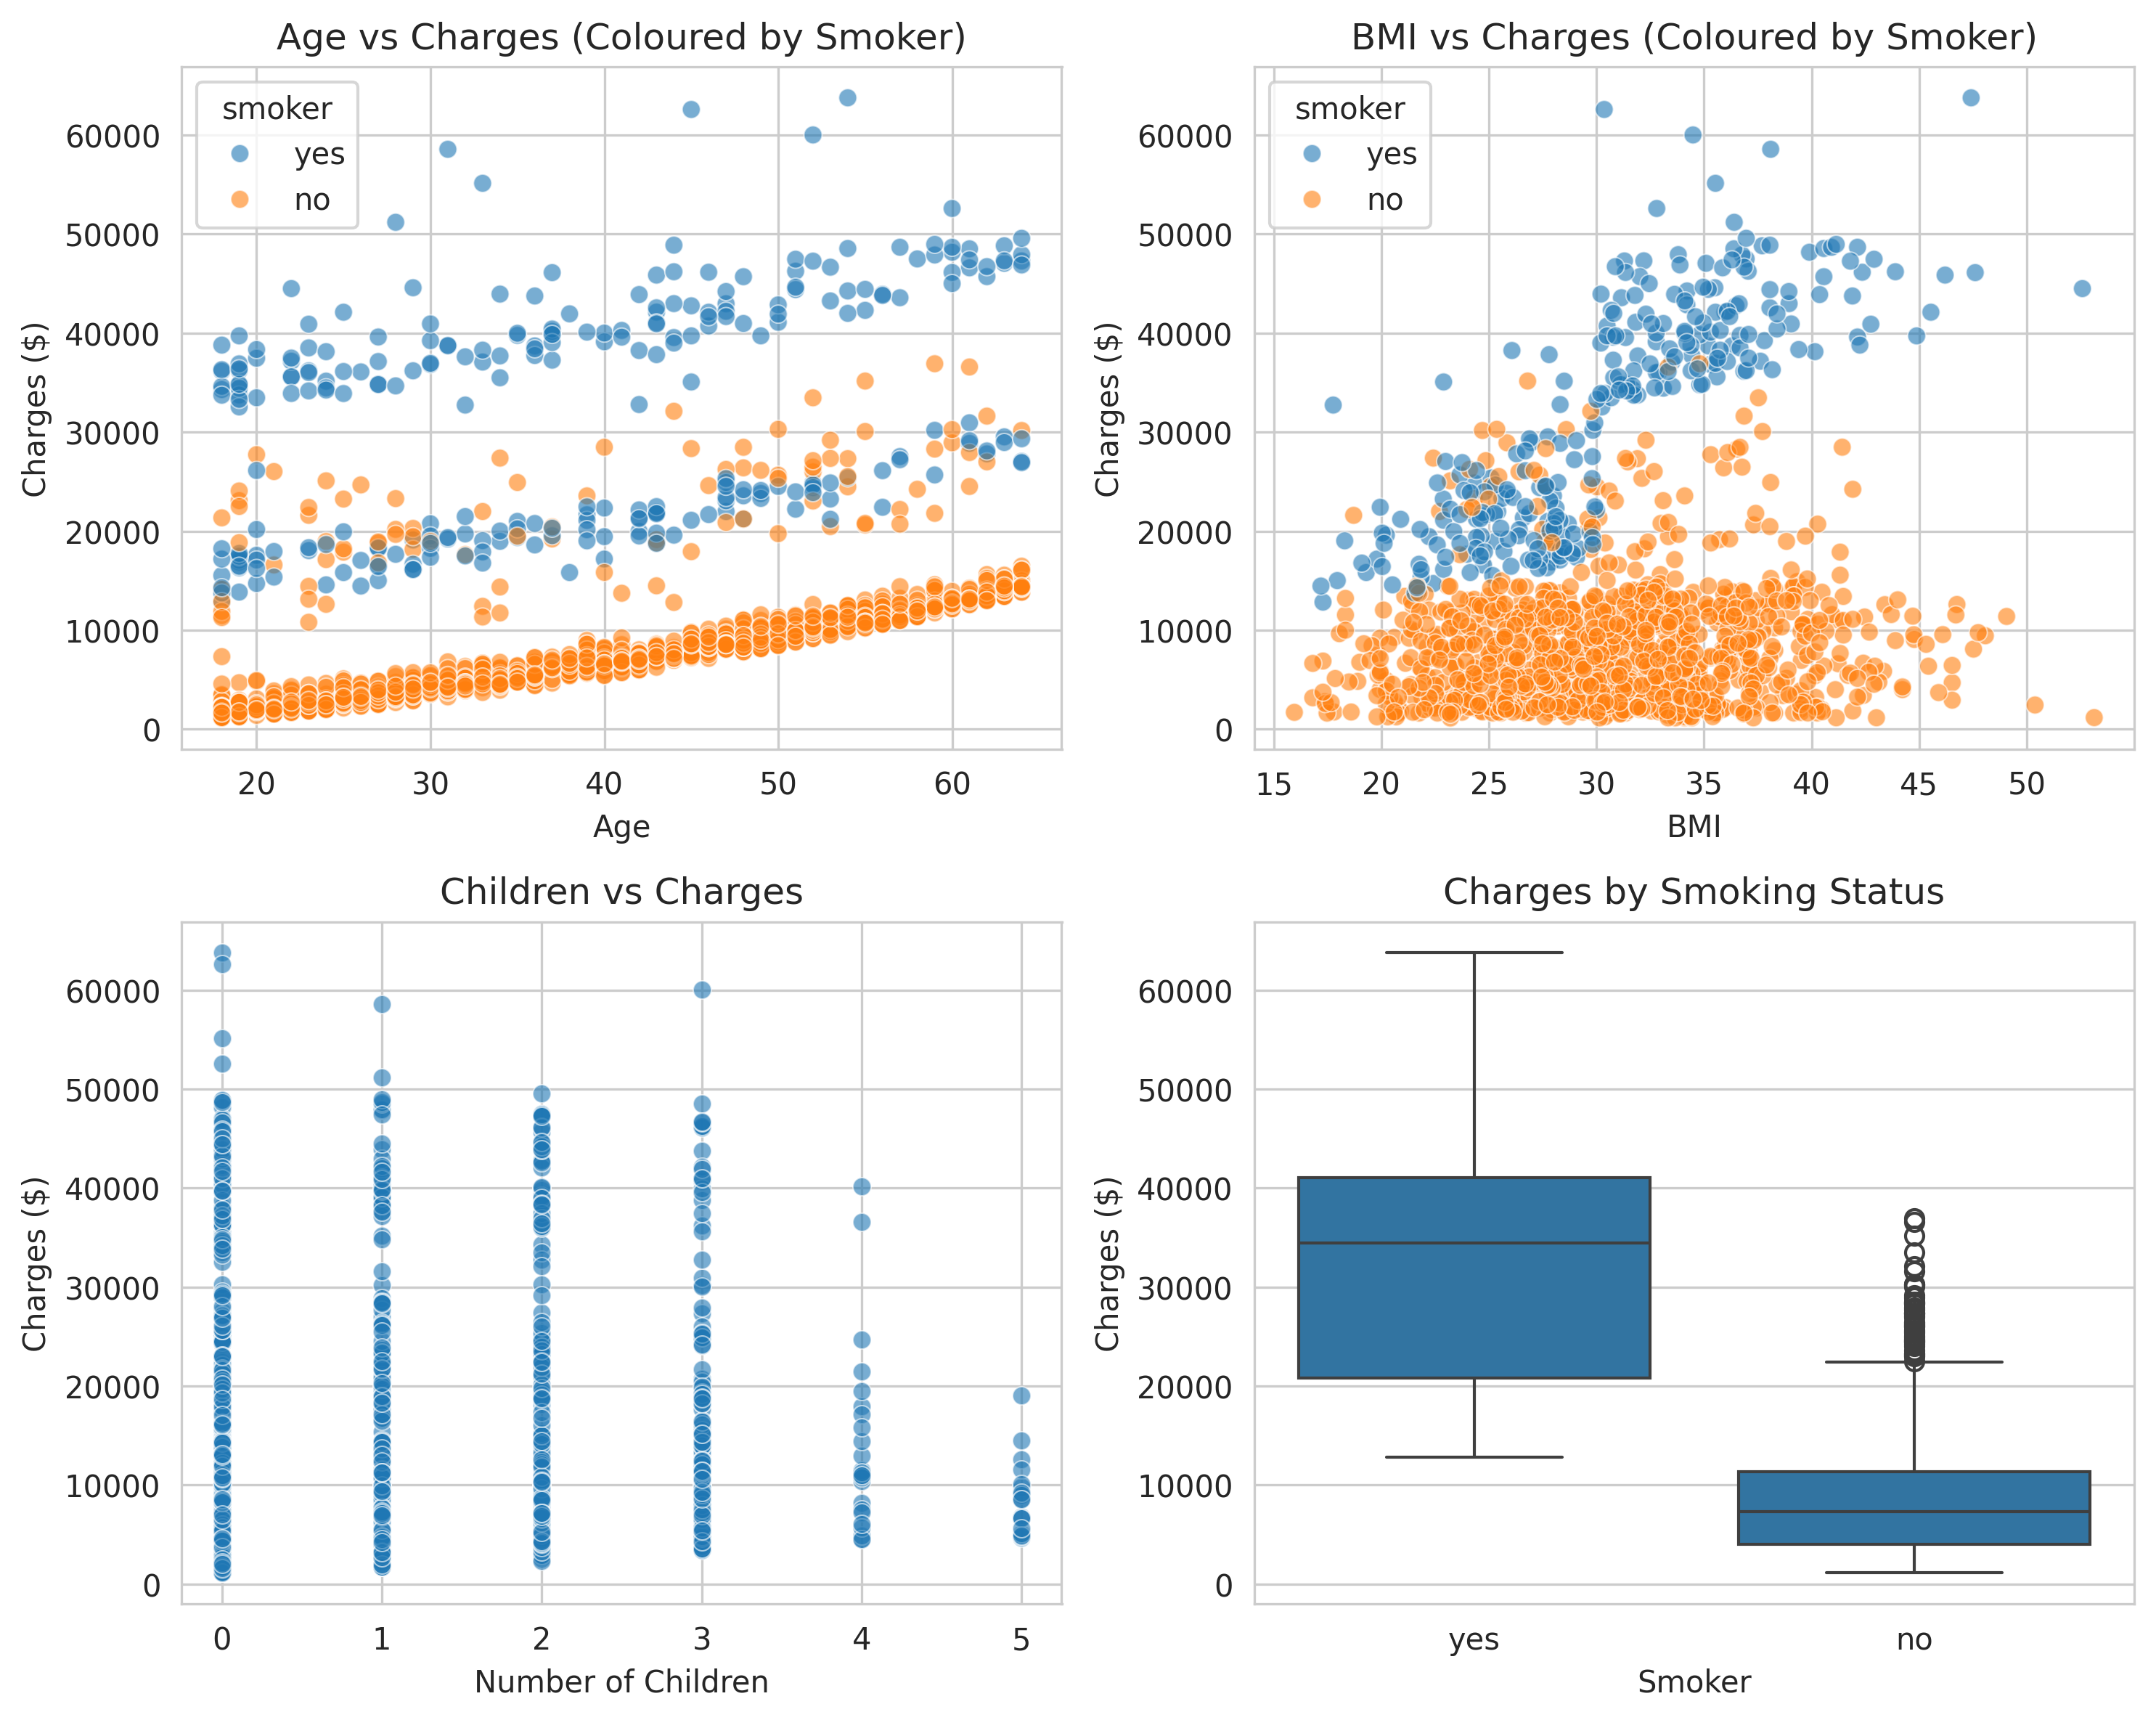

In [20]:
# ============================================================
# STEP 6: Create Bivariate Visualisations (Test Linearity)
# Purpose: Assess linear relationships between predictors and target
# Reference: (James et al, 2023)
# ============================================================

# Create scatter plots with regression lines
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Age vs Charges (coloured by smoker status)
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title('Age vs Charges (Coloured by Smoker)')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Charges ($)')

# BMI vs Charges (coloured by smoker status)
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title('BMI vs Charges (Coloured by Smoker)')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Charges ($)')

# Children vs Charges
sns.scatterplot(data=df, x='children', y='charges', alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title('Children vs Charges')
axes[1, 0].set_xlabel('Number of Children')
axes[1, 0].set_ylabel('Charges ($)')

# Boxplot: Smoker vs Charges
sns.boxplot(data=df, x='smoker', y='charges', ax=axes[1, 1])
axes[1, 1].set_title('Charges by Smoking Status')
axes[1, 1].set_xlabel('Smoker')
axes[1, 1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.savefig('bivariate_visualisations.png', dpi=300)
plt.show()


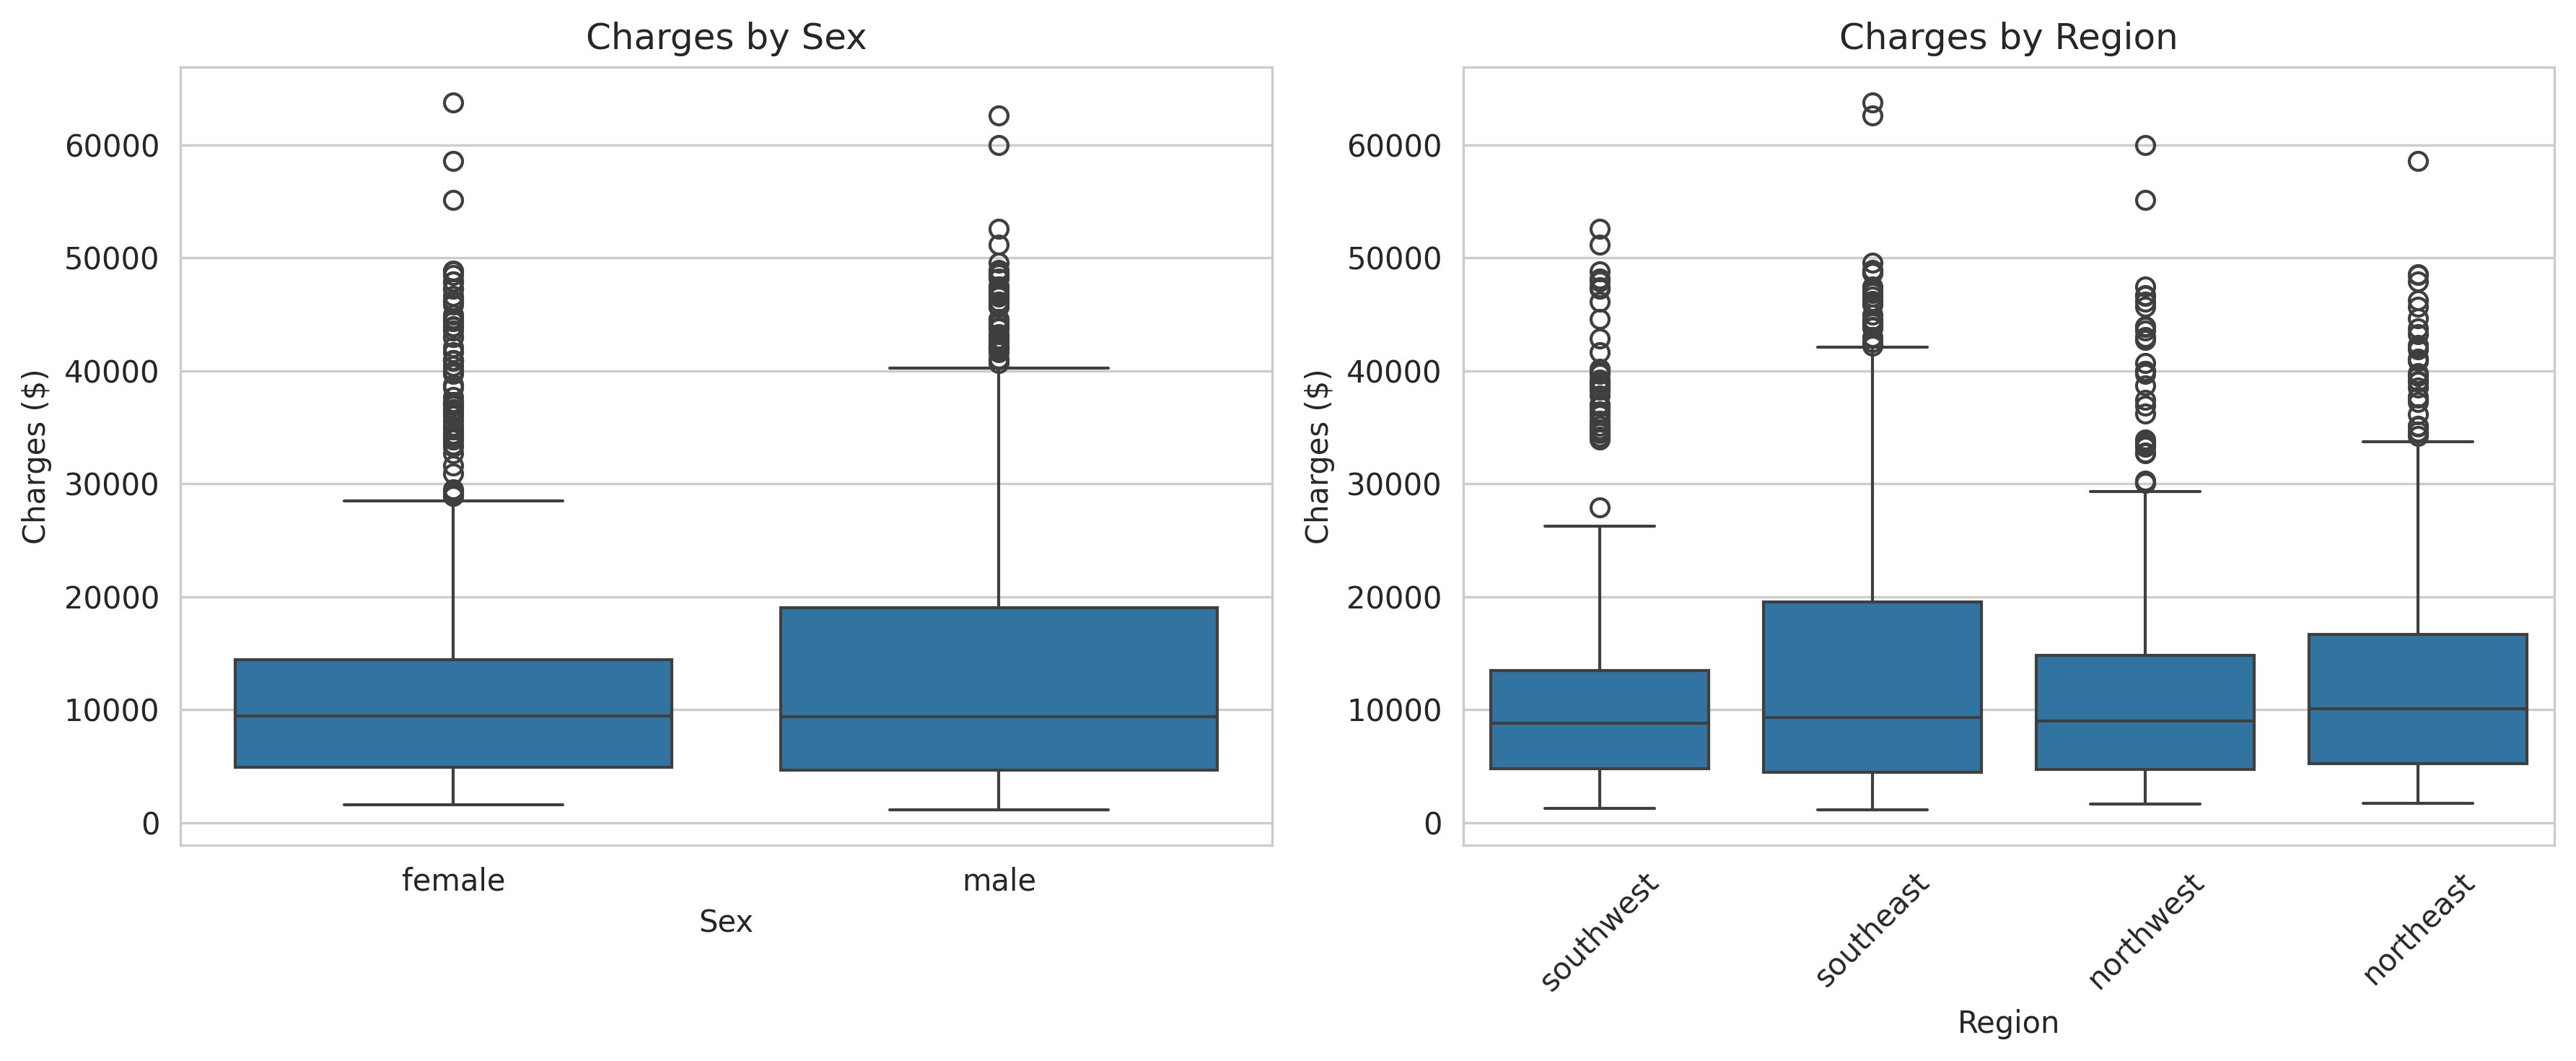

In [21]:

# Additional boxplots for sex and region
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sex vs Charges
sns.boxplot(data=df, x='sex', y='charges', ax=axes[0])
axes[0].set_title('Charges by Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Charges ($)')

# Region vs Charges
sns.boxplot(data=df, x='region', y='charges', ax=axes[1])
axes[1].set_title('Charges by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Charges ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('categorical_boxplots.png', dpi=150)
plt.show()

In [22]:
# ============================================================
# STEP 7: Conduct Statistical Tests for Categorical Predictors
# Purpose: Quantify significance of categorical variables
# Reference: (McKinney, 2022)
# ============================================================

print("\n=== STATISTICAL TESTS FOR CATEGORICAL PREDICTORS ===")

# T-test for Sex (male vs female)
male_charges = df[df['sex'] == 'male']['charges']
female_charges = df[df['sex'] == 'female']['charges']
t_stat_sex, p_val_sex = stats.ttest_ind(male_charges, female_charges)
print(f"Sex T-test: t-statistic = {t_stat_sex:.4f}, p-value = {p_val_sex:.4f}")
if p_val_sex < 0.05:
    print("  -> Sex is significant at p < 0.05\n")
else:
    print("  -> Sex is not significant at p < 0.05\n")

# T-test for Smoker (yes vs no)
smoker_charges = df[df['smoker'] == 'yes']['charges']
non_smoker_charges = df[df['smoker'] == 'no']['charges']
t_stat_smoker, p_val_smoker = stats.ttest_ind(smoker_charges, non_smoker_charges)
print(f"Smoker T-test: t-statistic = {t_stat_smoker:.4f}, p-value = {p_val_smoker:.4f}")
if p_val_smoker < 0.05:
    print("  -> Smoking is significant at p < 0.05\n")
else:
    print("  -> Smoking is not significant at p < 0.05\n")

# ANOVA for Region
region_groups = [df[df['region'] == region]['charges'] for region in df['region'].unique()]
f_stat_region, p_val_region = stats.f_oneway(*region_groups)
print(f"Region ANOVA: F-statistic = {f_stat_region:.4f}, p-value = {p_val_region:.4f}")
if p_val_region < 0.05:
    print("  -> Region is significant at p < 0.05\n")
else:
    print("  -> Region is not significant at p < 0.05\n")


=== STATISTICAL TESTS FOR CATEGORICAL PREDICTORS ===
Sex T-test: t-statistic = 2.1244, p-value = 0.0338
  -> Sex is significant at p < 0.05

Smoker T-test: t-statistic = 46.6448, p-value = 0.0000
  -> Smoking is significant at p < 0.05

Region ANOVA: F-statistic = 2.9261, p-value = 0.0328
  -> Region is significant at p < 0.05



In [23]:
# ============================================================
# STEP 8: Detect and Handle Outliers
# Purpose: Identify extreme values using IQR method and cap if necessary
# ============================================================

print("\n=== OUTLIER DETECTION (IQR METHOD) ===\n")

# Function to detect outliers using IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Check outliers in charges
charges_outliers, charges_lower, charges_upper = detect_outliers_iqr(df, 'charges')
print(f"Charges: {charges_outliers} outliers detected\n")
print(f"  Upper bound: ${charges_upper:,.2f}\n")
print(f"  Maximum value: ${df['charges'].max():,.2f}\n")

# Cap outliers at 99th percentile for charges (preserve distribution)
charges_99th = df['charges'].quantile(0.99)
print(f"  99th percentile: ${charges_99th:,.2f}\n")

# Create a copy before capping
df_clean = df.copy()
df_clean['charges'] = np.where(df_clean['charges'] > charges_99th, charges_99th, df_clean['charges'])
print(f"Charges outliers capped at 99th percentile. New max: ${df_clean['charges'].max():,.2f}\n")

# Check outliers in BMI (retain as clinically valid)
bmi_outliers, bmi_lower, bmi_upper = detect_outliers_iqr(df, 'bmi')
print(f"BMI: {bmi_outliers} outliers detected (retained as clinically valid)\n")


=== OUTLIER DETECTION (IQR METHOD) ===

Charges: 139 outliers detected

  Upper bound: $34,524.78

  Maximum value: $63,770.43

  99th percentile: $48,537.80

Charges outliers capped at 99th percentile. New max: $48,537.80

BMI: 9 outliers detected (retained as clinically valid)



In [24]:
# delete charge outliers
df_clean = df_clean[df_clean['charges'] <= charges_99th]
print(f"Charges outliers capped at 99th percentile. New max: ${df_clean['charges'].max():,.2f}\n")

Charges outliers capped at 99th percentile. New max: $48,537.80



In [25]:
df_clean['charges'].info()

<class 'pandas.core.series.Series'>
Index: 1337 entries, 0 to 1337
Series name: charges
Non-Null Count  Dtype  
--------------  -----  
1337 non-null   float64
dtypes: float64(1)
memory usage: 20.9 KB


In [26]:
# ============================================================
# STEP 9: Encode Categorical Variables
# Purpose: Convert categorical variables to numerical format for modelling
# ============================================================

print("\n=== ENCODING CATEGORICAL VARIABLES ===\n")

# Create a copy for encoding
df_encoded = df_clean.copy()

# Binary encoding for sex (male = 1, female = 0)
df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})
print("Sex encoded: male=1, female=0")

# Binary encoding for smoker (yes = 1, no = 0)
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
print("Smoker encoded: yes=1, no=0")

# One-hot encoding for region with drop_first to avoid dummy variable trap
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)
print("Region one-hot encoded with drop_first=True with region_northeast as reference\n")
print(f"New columns: {df_encoded.columns.tolist()}\n")

print("\nFirst 5 rows of encoded dataset:")
print(df_encoded.head())


=== ENCODING CATEGORICAL VARIABLES ===

Sex encoded: male=1, female=0
Smoker encoded: yes=1, no=0
Region one-hot encoded with drop_first=True with region_northeast as reference

New columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


First 5 rows of encoded dataset:
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061              True   
4   32    1  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False      

In [27]:
# check records that are region_northeast from the one-hot encoding
region_northeast_rows = df_encoded[
    (df_encoded['region_northwest'] == False) &
    (df_encoded['region_southwest'] == False) &
    (df_encoded['region_southeast'] == False)
]
print(f"Count of 'northeast' region rows: {len(region_northeast_rows)}\n")
print("Rows where region is 'northeast':")
display(region_northeast_rows.head())



Count of 'northeast' region rows: 324

Rows where region is 'northeast':


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
8,37,1,29.830,2,0,6406.41070,False,False,False
10,25,1,26.220,0,0,2721.32080,False,False,False
16,52,0,30.780,1,0,10797.33620,False,False,False
17,23,1,23.845,0,0,2395.17155,False,False,False
20,60,0,36.005,0,0,13228.84695,False,False,False


In [28]:
# check that there are no more categorical fields and all objects are encoded
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   sex               1337 non-null   int64  
 2   bmi               1337 non-null   float64
 3   children          1337 non-null   int64  
 4   smoker            1337 non-null   int64  
 5   charges           1337 non-null   float64
 6   region_northwest  1337 non-null   bool   
 7   region_southeast  1337 non-null   bool   
 8   region_southwest  1337 non-null   bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 77.0 KB



=== CORRELATION ANALYSIS ===
Correlation with target variable (charges):
charges             1.000000
smoker              0.790154
age                 0.300596
bmi                 0.196643
region_southeast    0.072749
children            0.069540
sex                 0.058811
region_northwest   -0.039529
region_southwest   -0.042915
Name: charges, dtype: float64




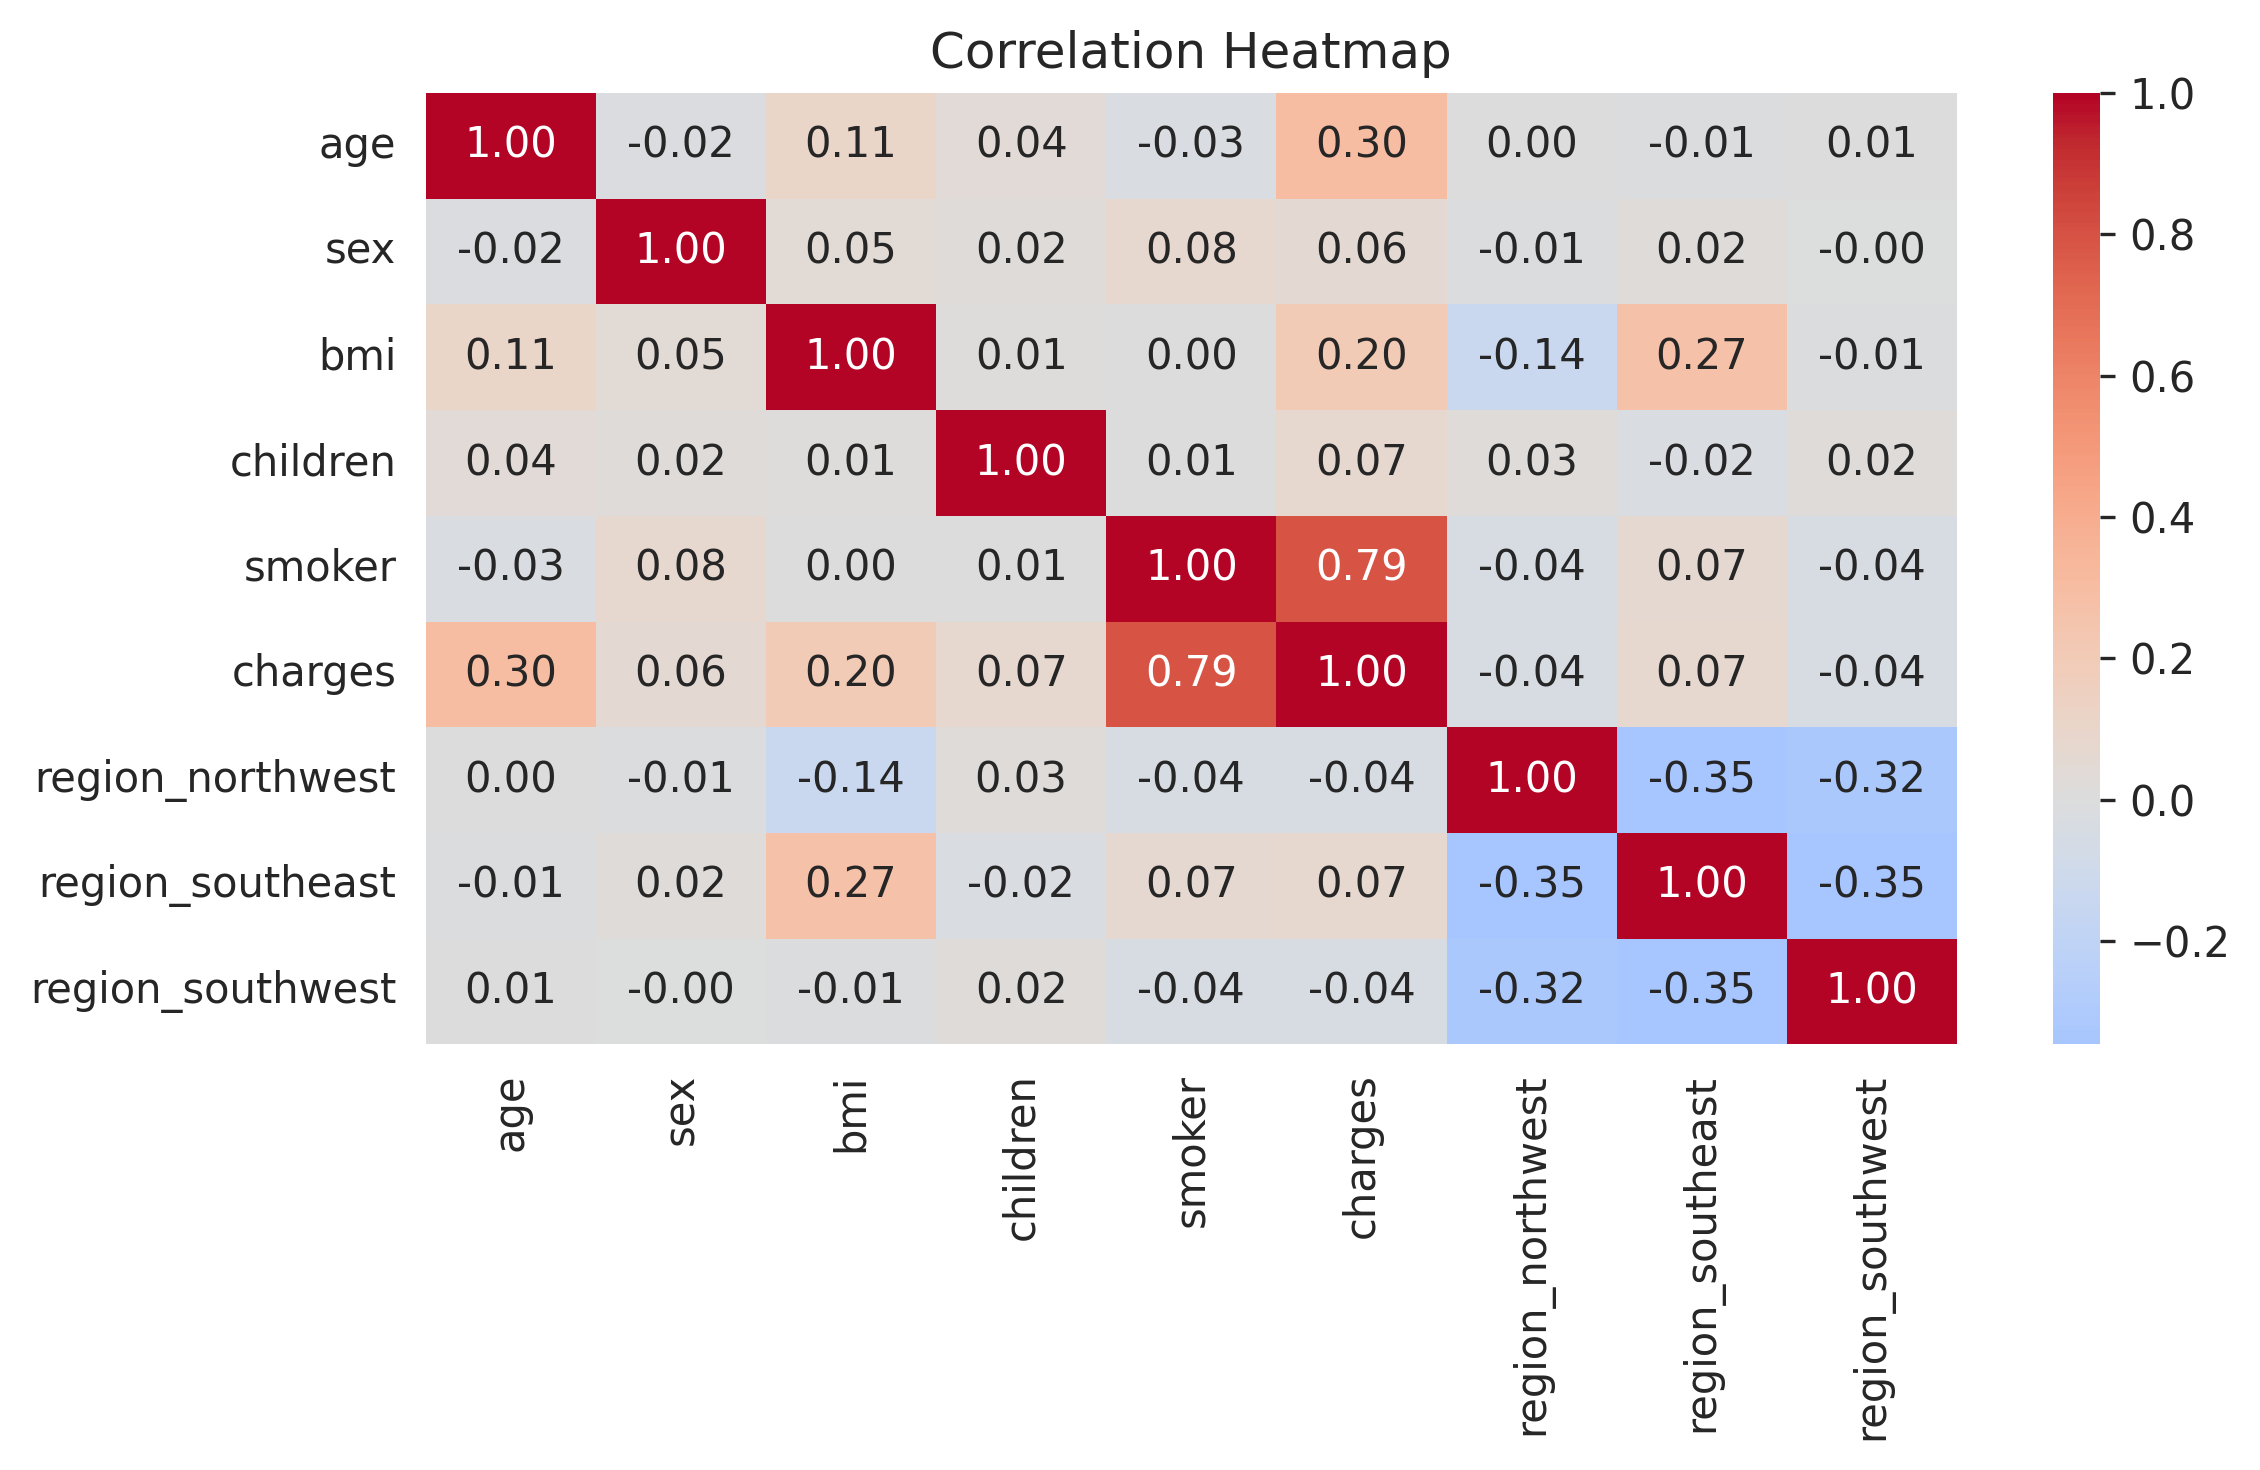

In [29]:
# ============================================================
# STEP 10: Correlation Analysis and VIF (Test Multicollinearity)
# Purpose: Identify correlations between predictors and calculate VIF
# ============================================================

print("\n=== CORRELATION ANALYSIS ===")

# Correlation matrix
correlation_matrix = df_encoded.corr()
print("Correlation with target variable (charges):")
print(correlation_matrix['charges'].sort_values(ascending=False))
print("\n")

# Heatmap of correlations
plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

In [30]:
# Calculate VIF for predictors
print("\n=== VARIANCE INFLATION FACTOR (VIF) ===")
X_vif = df_encoded.drop('charges', axis=1)
# Convert boolean columns to int for VIF calculation
for col in X_vif.select_dtypes(include=['bool']).columns:
    X_vif[col] = X_vif[col].astype(int)
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data.to_string(index=False))

# Check for VIF > 5 (indicates concerning multicollinearity)
high_vif = vif_data[vif_data['VIF'] > 5]
if len(high_vif) > 0:
    print(f"\nWarning: Features with VIF > 5: {high_vif['Feature'].tolist()}")
else:
    print("\nAll VIF values < 5: No concerning multicollinearity detected")


=== VARIANCE INFLATION FACTOR (VIF) ===
         Feature       VIF
             age  7.696862
             sex  2.001959
             bmi 11.359739
        children  1.810971
          smoker  1.261476
region_northwest  1.888020
region_southeast  2.265574
region_southwest  1.960750



Both Age and BMI though having a high VIF, are important factors for determining medical charges. The two columns will not be dropped.


=== LOG TRANSFORMATION OF CHARGES ===
Skewness before log transformation: 1.446
Skewness after log transformation: -0.099


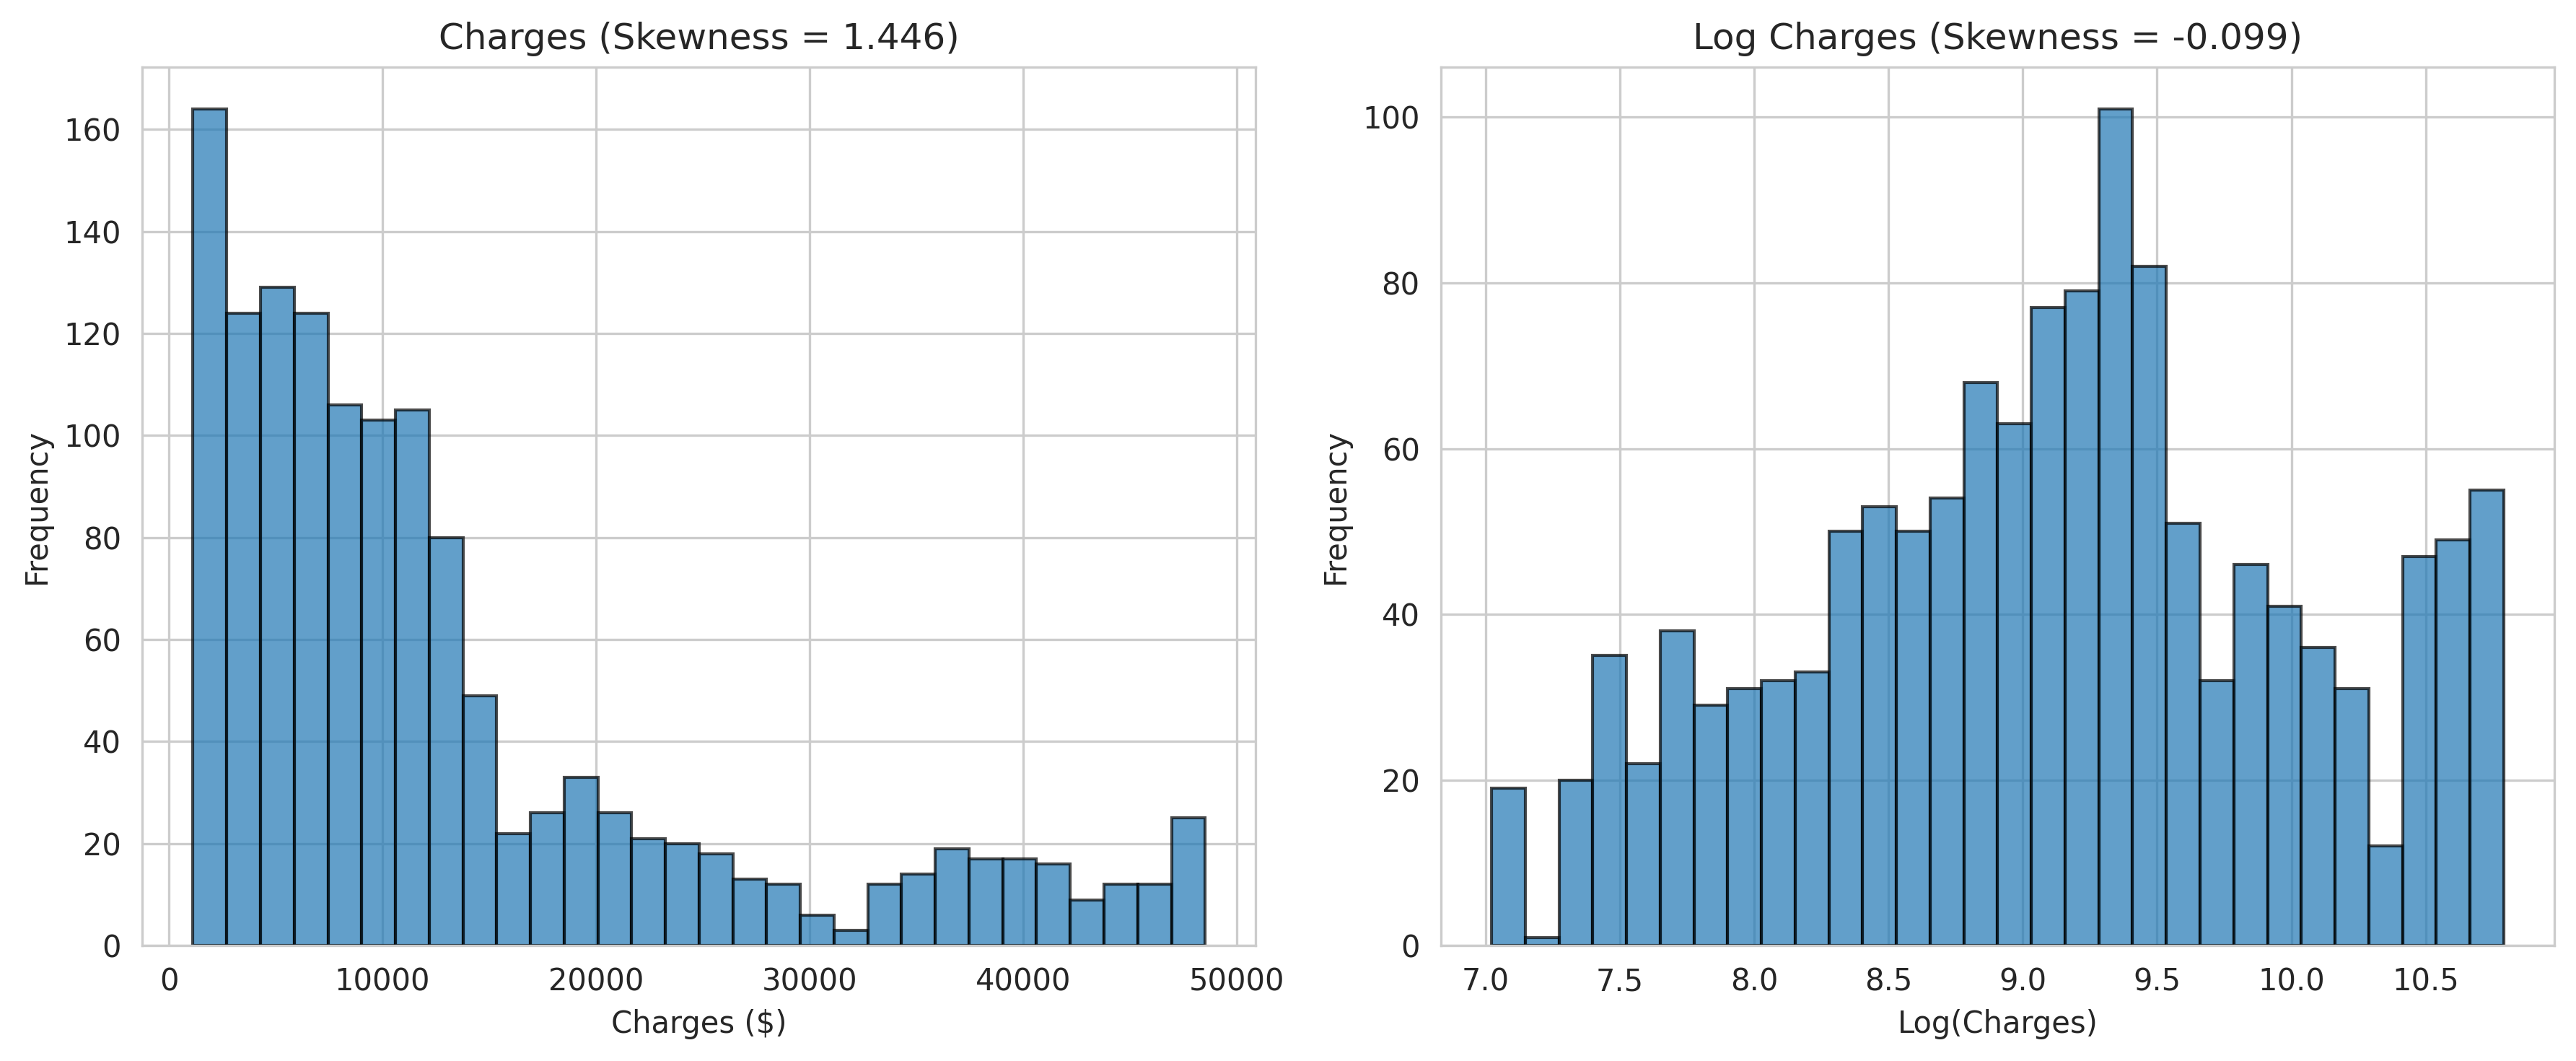

In [31]:
# ============================================================
# STEP 11: Log Transformation of Target Variable
# Purpose: Address skewness in charges to improve model performance
# Reference: (James et al, 2023)
# ============================================================

print("\n=== LOG TRANSFORMATION OF CHARGES ===")

# Check skewness before transformation
skew_before = df_encoded['charges'].skew()
print(f"Skewness before log transformation: {skew_before:.3f}")

# Apply natural log transformation
df_encoded['log_charges'] = np.log(df_encoded['charges'])

# Check skewness after transformation
skew_after = df_encoded['log_charges'].skew()
print(f"Skewness after log transformation: {skew_after:.3f}")

# Visualise before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_encoded['charges'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Charges (Skewness = {skew_before:.3f})')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_encoded['log_charges'], bins=30, edgecolor='black', alpha=0.7)
axes[1].set_title(f'Log Charges (Skewness = {skew_after:.3f})')
axes[1].set_xlabel('Log(Charges)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('log_transformation.png', dpi=300)
plt.show()

Use of the log transformation will improve the model.

In [32]:
# ============================================================
# STEP 12: Feature Selection using Backward Elimination
# Purpose: Select best features using p-value thresholds (p < 0.05)
# ============================================================

print("\n=== FEATURE SELECTION (BACKWARD ELIMINATION) ===")

# Prepare data for statsmodels
X = df_encoded.drop(['charges', 'log_charges'], axis=1)
y = df_encoded['log_charges']

# Convert boolean columns to int for statsmodels
for col in X.select_dtypes(include=['bool']).columns:
    X[col] = X[col].astype(int)

# Add constant term for intercept
X_with_const = sm.add_constant(X)

# Fit full model
model_full = sm.OLS(y, X_with_const).fit()
print("\nFull Model Summary:")
print(model_full.summary())


=== FEATURE SELECTION (BACKWARD ELIMINATION) ===

Full Model Summary:
                            OLS Regression Results                            
Dep. Variable:            log_charges   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     547.6
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:29:12   Log-Likelihood:                -805.74
No. Observations:                1337   AIC:                             1629.
Df Residuals:                    1328   BIC:                             1676.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

In [33]:
# Backward elimination based on p-values
print("\n=== BACKWARD ELIMINATION PROCESS ===")

# Start with all features
selected_features = X.columns.tolist()
removed_features = []

while True:
    # Fit model with current features
    X_current = df_encoded[selected_features]
    # Convert boolean columns to int for statsmodels within the loop
    for col in X_current.select_dtypes(include=['bool']).columns:
        X_current[col] = X_current[col].astype(int)
    X_current_const = sm.add_constant(X_current)
    model_current = sm.OLS(y, X_current_const).fit()

    # Get p-values (excluding constant)
    p_values = model_current.pvalues.drop('const')

    # Find feature with highest p-value
    max_p = p_values.max()
    max_p_feature = p_values.idxmax()

    print(f"Highest p-value: {max_p_feature} = {max_p:.4f}")

    # Stop if all p-values < 0.05
    if max_p < 0.05:
        print("All remaining features have p-value < 0.05")
        break

    # Remove feature with highest p-value
    selected_features.remove(max_p_feature)
    removed_features.append(max_p_feature)
    print(f"Removed: {max_p_feature}")
    print(f"Remaining features: {selected_features}")

print(f"\nFinal selected features: {selected_features}")
print(f"Removed features: {removed_features}")


=== BACKWARD ELIMINATION PROCESS ===
Highest p-value: region_northwest = 0.0726
Removed: region_northwest
Remaining features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_southeast', 'region_southwest']
Highest p-value: sex = 0.0025
All remaining features have p-value < 0.05

Final selected features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_southeast', 'region_southwest']
Removed features: ['region_northwest']


/tmp/ipykernel_7458/894285734.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_current[col] = X_current[col].astype(int)
/tmp/ipykernel_7458/894285734.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_current[col] = X_current[col].astype(int)
/tmp/ipykernel_7458/894285734.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

In [34]:
# Final selected features
df_encoded[selected_features].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   sex               1337 non-null   int64  
 2   bmi               1337 non-null   float64
 3   children          1337 non-null   int64  
 4   smoker            1337 non-null   int64  
 5   region_southeast  1337 non-null   bool   
 6   region_southwest  1337 non-null   bool   
dtypes: bool(2), float64(1), int64(4)
memory usage: 65.3 KB


In [35]:
# Fit final model with selected features
X_final = df_encoded[selected_features]
# Convert boolean columns to int for statsmodels
for col in X_final.select_dtypes(include=['bool']).columns:
    X_final[col] = X_final[col].astype(int)
X_final_const = sm.add_constant(X_final)
model_final = sm.OLS(y, X_final_const).fit()
print("\nFinal Model Summary:")
print(model_final.summary())


Final Model Summary:
                            OLS Regression Results                            
Dep. Variable:            log_charges   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.766
Method:                 Least Squares   F-statistic:                     624.3
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:29:40   Log-Likelihood:                -807.36
No. Observations:                1337   AIC:                             1631.
Df Residuals:                    1329   BIC:                             1672.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             

/tmp/ipykernel_7458/4100185310.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_final[col] = X_final[col].astype(int)
/tmp/ipykernel_7458/4100185310.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_final[col] = X_final[col].astype(int)



### 3.3 Train Model

In [36]:
# ============================================================
# STEP 13: Train Linear Regression Model
# Purpose: Train model using LinearRegression() from scikit-learn
# Reference: (Lavin, 2022)
# ============================================================

print("\n=== TRAIN LINEAR REGRESSION MODEL ===")

# Prepare final features and target
X_train_model = df_encoded[selected_features]
y_train_model = df_encoded['log_charges']

# Split data into 80% training and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_train_model, y_train_model, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} observations")
print(f"Test set size: {X_test.shape[0]} observations")
print(f"Features used: {X_train.columns.tolist()}")



=== TRAIN LINEAR REGRESSION MODEL ===
Training set size: 1069 observations
Test set size: 268 observations
Features used: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_southeast', 'region_southwest']


In [37]:
# Standardise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures standardised using StandardScaler")



Features standardised using StandardScaler


In [38]:
# Train linear regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)



LinearRegression()

In [39]:
print("\nModel training complete")
print(f"Intercept: {model.intercept_:.4f}")
print("Coefficients:")
for feature, coef in zip(X_train.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")


Model training complete
Intercept: 9.0911
Coefficients:
  age: 0.4758
  sex: -0.0385
  bmi: 0.0788
  children: 0.1184
  smoker: 0.6148
  region_southeast: -0.0472
  region_southwest: -0.0340


In [40]:
# ============================================================
# STEP 14: Make Predictions and Evaluate Model
# Purpose: Generate predictions and assess model performance
# Reference: (James et al., 2023)
# ============================================================

print("\n=== MODEL PREDICTIONS AND EVALUATION ===")

# Make predictions on test set
y_pred_log = model.predict(X_test_scaled)
score = model.score(X_test_scaled,y_test)
print(f"Model score: {score:.4f}")





=== MODEL PREDICTIONS AND EVALUATION ===
Model score: 0.8269


Model score is above 80% which is good.

In [41]:
# Convert predictions back to original dollar scale
y_pred_original = np.exp(y_pred_log)
y_test_original = np.exp(y_test)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae = mean_absolute_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

print(f"RMSE (Root Mean Squared Error): ${rmse:,.2f}")
print(f"MAE (Mean Absolute Error): ${mae:,.2f}")
print(f"R² (R-squared): {r2:.4f}")


RMSE (Root Mean Squared Error): $7,147.78
MAE (Mean Absolute Error): $3,780.80
R² (R-squared): 0.7039


In [42]:
# Calculate adjusted R-squared
n = len(y_test_original)
k = X_test_scaled.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
print(f"Adjusted R²: {adj_r2:.4f}")

# Business interpretation: Dollar impact for baseline customer
print("\n=== BUSINESS INTERPRETATION (Dollar Impact) ===")
print("For a baseline customer with $10,000 in predicted charges:")
baseline = 10000
for feature, coef in zip(X_train.columns, model.coef_):
    pct_change = np.exp(coef) - 1
    dollar_impact = baseline * pct_change
    print(f"  {feature}: {pct_change:+.1%} change = ${dollar_impact:+,.0f}")

Adjusted R²: 0.6959

=== BUSINESS INTERPRETATION (Dollar Impact) ===
For a baseline customer with $10,000 in predicted charges:
  age: +60.9% change = $+6,093
  sex: -3.8% change = $-378
  bmi: +8.2% change = $+820
  children: +12.6% change = $+1,257
  smoker: +84.9% change = $+8,494
  region_southeast: -4.6% change = $-461
  region_southwest: -3.3% change = $-334


In [43]:
print("\nModel training complete")
print(f"Intercept: {model.intercept_:.4f}")
print("Coefficients:")
for feature, coef in zip(X_train.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")


Model training complete
Intercept: 9.0911
Coefficients:
  age: 0.4758
  sex: -0.0385
  bmi: 0.0788
  children: 0.1184
  smoker: 0.6148
  region_southeast: -0.0472
  region_southwest: -0.0340


In [44]:
# Test to predict for a 40-year-old male smoker with BMI 30, two children, in the  Southwest region
# Create a DataFrame for the new individual
new_individual_data = pd.DataFrame({
    'age': [40],
    'sex': [1],  # Male
    'bmi': [30],
    'children': [2],
    'smoker': [1], # Yes
    'region_southeast': [0],
    'region_southwest': [1] # Southwest
})

# Ensure the columns are in the same order as the training data
new_individual_data = new_individual_data[X_train.columns]

# Scale the new individual's data using the trained scaler
new_individual_scaled = scaler.transform(new_individual_data)

# Predict the log charges
predicted_log_charges = model.predict(new_individual_scaled)

# Convert the log charges back to original dollar scale
predicted_charges = np.exp(predicted_log_charges)

print(f"Predicted charges for the individual: ${predicted_charges[0]:,.2f}")

Predicted charges for the individual: $31,669.38



=== RESIDUAL DIAGNOSTICS ===


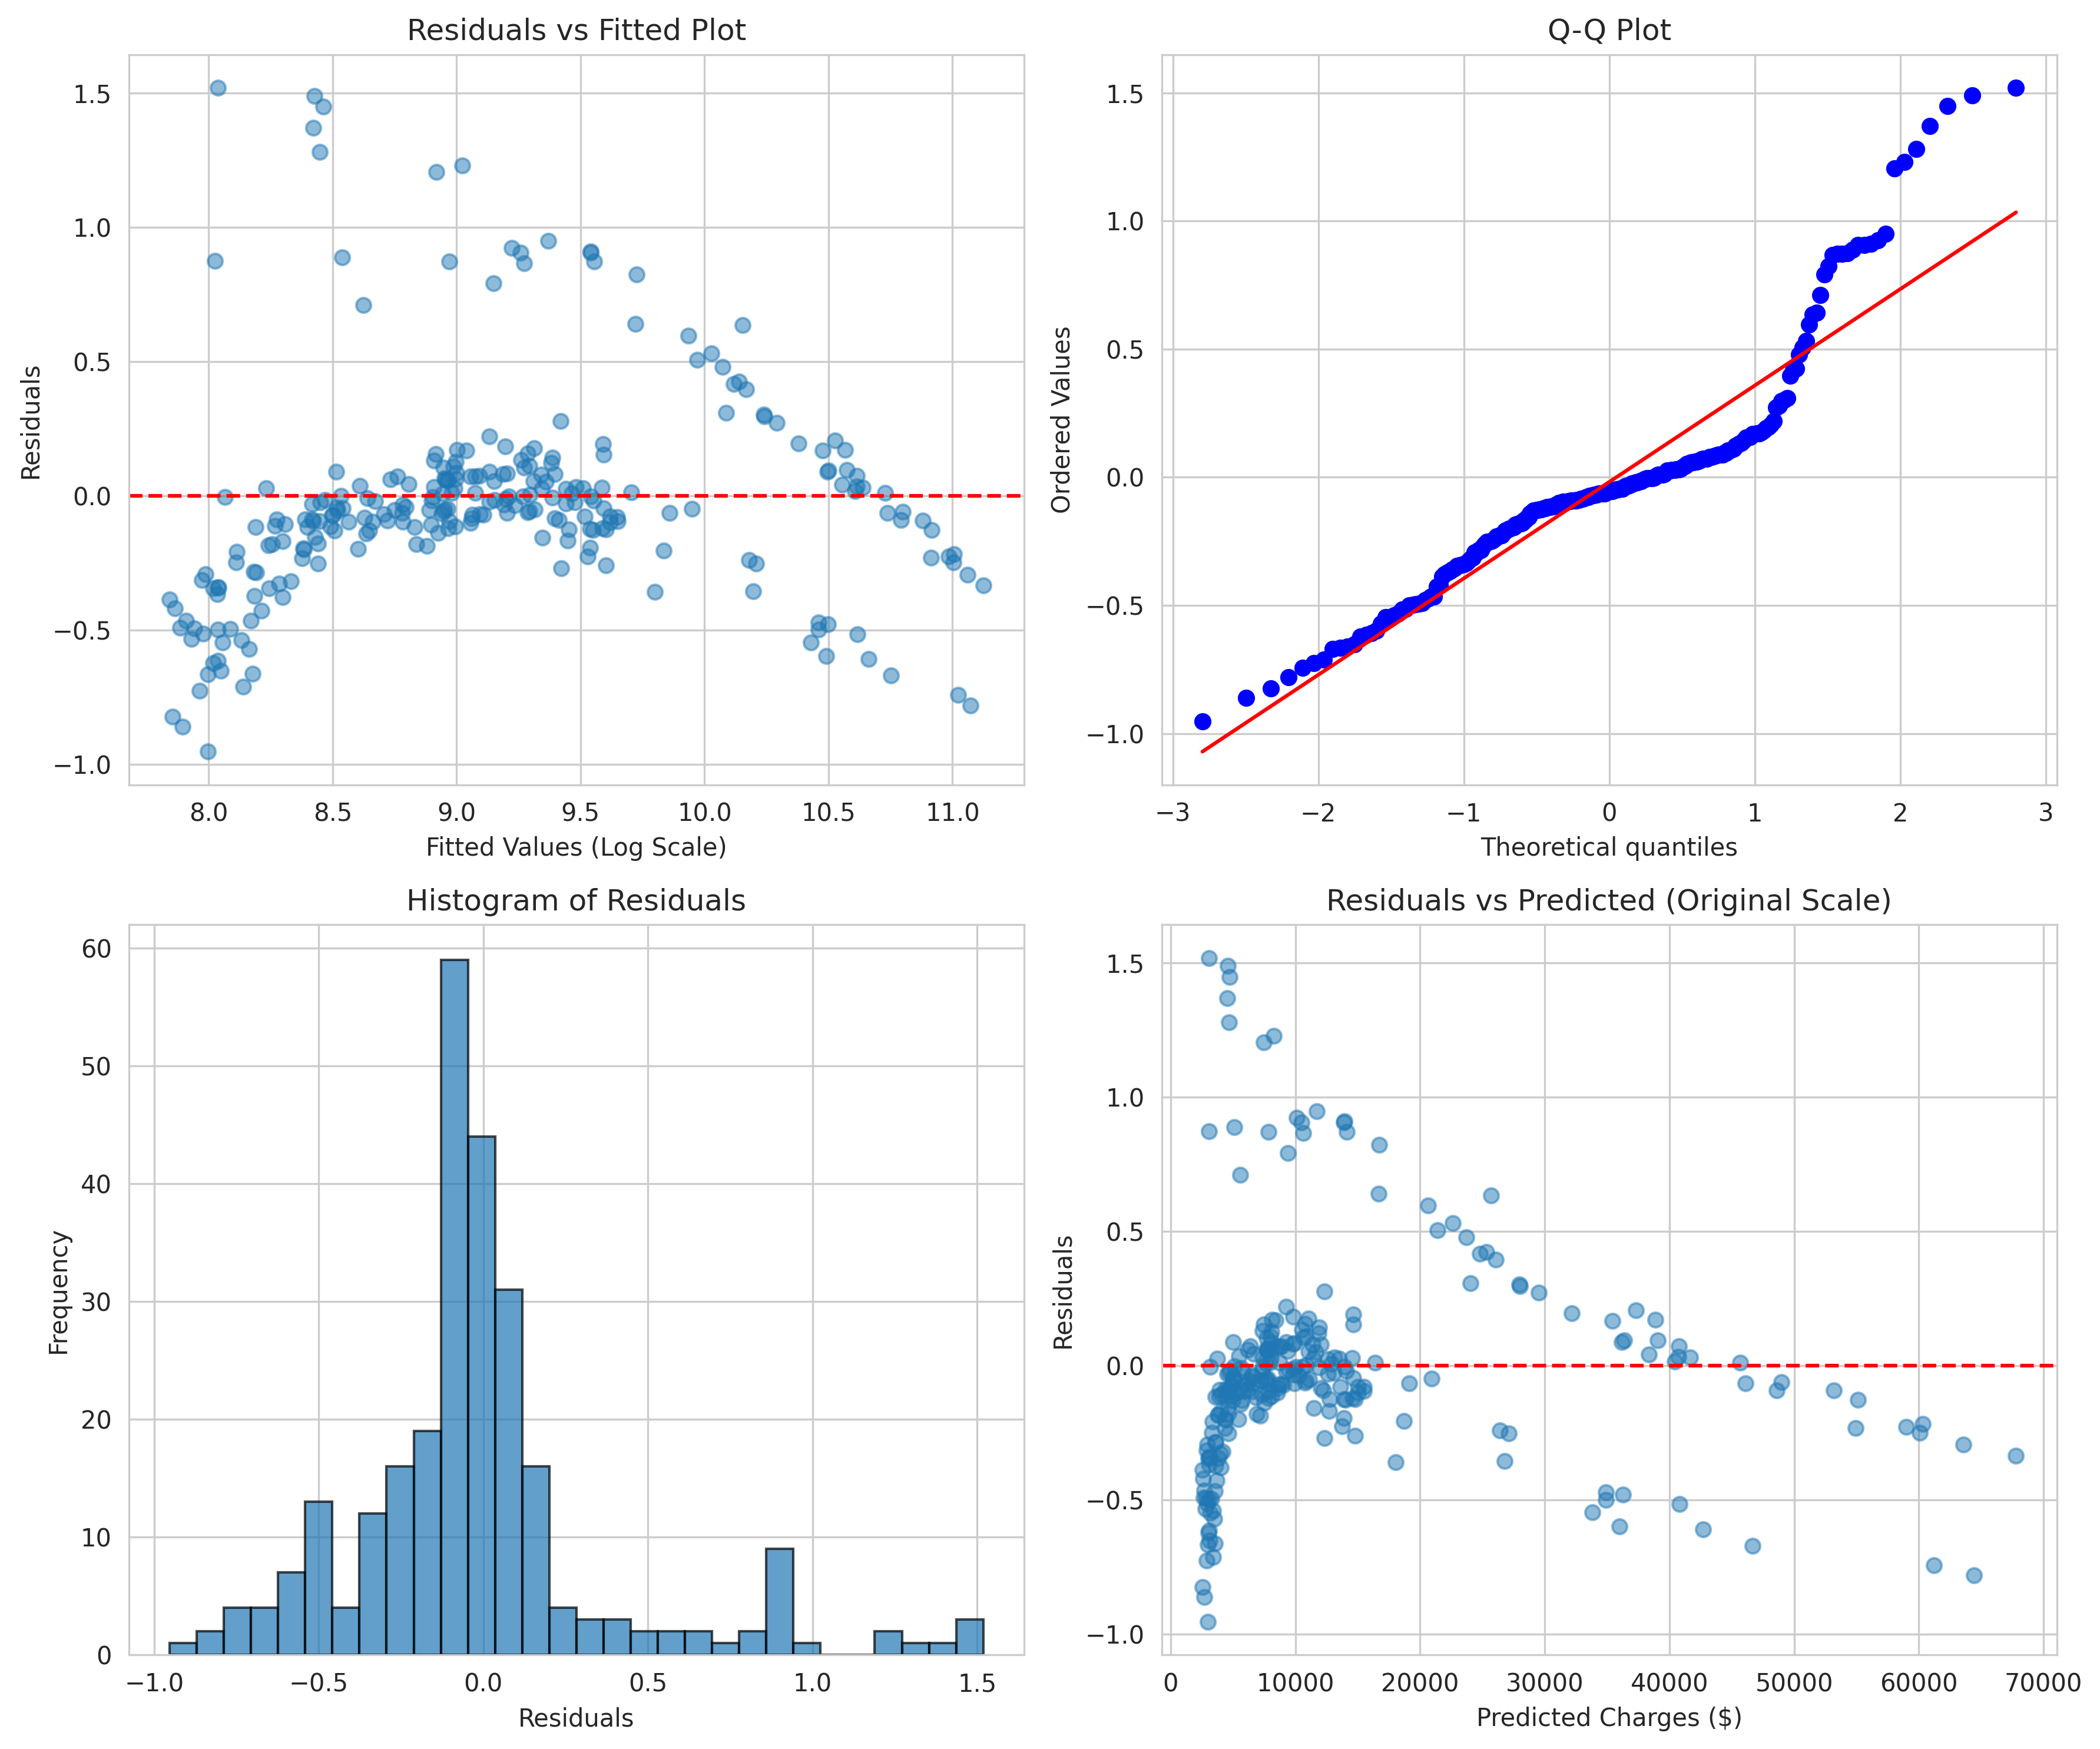

In [45]:
# ============================================================
# STEP 15: Residual Diagnostics
# Purpose: Validate linear regression assumptions
# Reference: (James et al, 2023), (Field, 2024)
# ============================================================

print("\n=== RESIDUAL DIAGNOSTICS ===")

# Calculate residuals
residuals = y_test - y_pred_log

# Residuals vs Fitted plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Residuals vs Fitted
axes[0, 0].scatter(y_pred_log, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Fitted Values (Log Scale)')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Plot')

# Plot 2: Q-Q Plot for normality
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot')

# Plot 3: Histogram of residuals
axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Histogram of Residuals')

# Plot 4: Residuals vs Predicted (original scale)
axes[1, 1].scatter(y_pred_original, residuals, alpha=0.5)
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Predicted Charges ($)')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residuals vs Predicted (Original Scale)')

plt.tight_layout()
plt.savefig('residual_diagnostics.png', dpi=150)
plt.show()


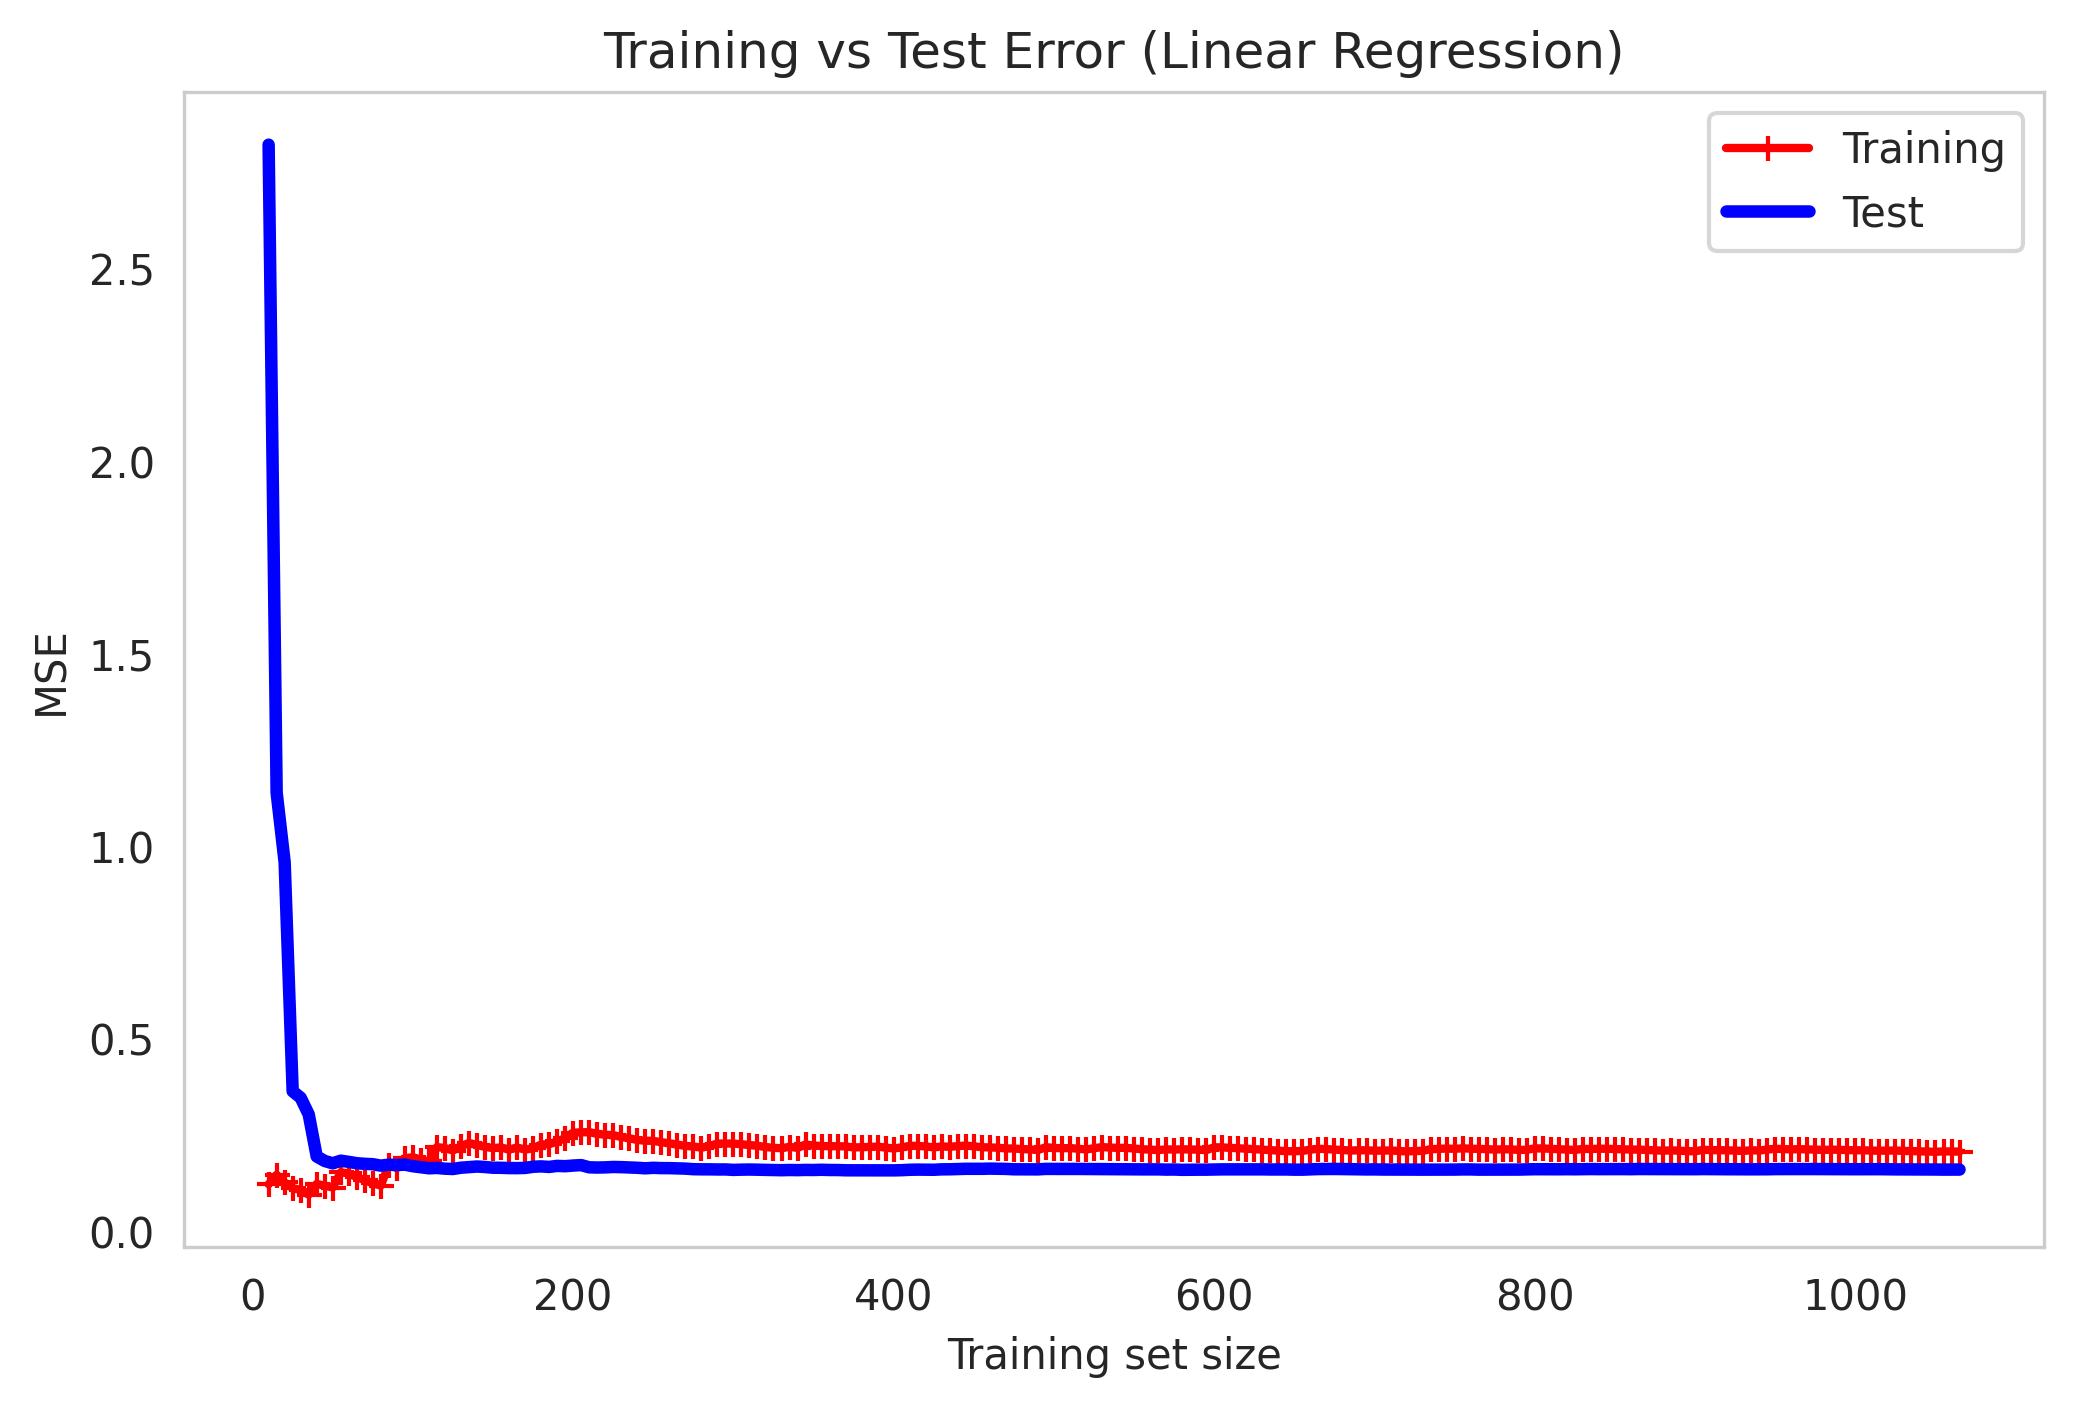

In [46]:
train_errors, val_errors = [], []
training_sizes = range(10, len(X_train_scaled), 5)

for m in training_sizes:
    model = LinearRegression().fit(X_train_scaled[:m], y_train[:m])
    y_train_predict = model.predict(X_train_scaled[:m])
    y_val_predict = model.predict(X_test_scaled)
    train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
    val_errors.append(mean_squared_error(y_test, y_val_predict))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(training_sizes, train_errors, "r-+", linewidth=2, label="Training")
plt.plot(training_sizes, val_errors, "b-", linewidth=3, label="Test")
plt.xlabel("Training set size")
plt.ylabel("MSE")
plt.title("Training vs Test Error (Linear Regression)")
plt.legend()
plt.grid()
plt.show()

In [47]:
# ============================================================
# STEP 16: Summary of Analysis Findings
# Purpose: Document key results from the analysis
# ============================================================

print("\n" + "="*60)
print("SUMMARY OF ANALYSIS FINDINGS")
print("="*60)

print("\n1. DATA QUALITY:")
print("   - No missing values found")
print(f"   - {duplicate_count} duplicate removed")
print("   - Data types correctly formatted")

print("\n2. EDA FINDINGS:")
print("   - Charges are right-skewed (log transformation applied)")
print(f"   - Smoker is highly significant (p = {p_val_smoker:.4f})")
print(f"   - Sex p-value: {p_val_sex:.4f}")
print(f"   - Region p-value: {p_val_region:.4f}")

print("\n3. FEATURE SELECTION:")
print(f"   - Selected features: {selected_features}")
print(f"   - Removed features: {removed_features}")

print("\n4. MODEL PERFORMANCE:")
print(f"   - Model Score: {score:,.4f}")
print(f"   - RMSE: ${rmse:,.2f}")
print(f"   - MAE: ${mae:,.2f}")
print(f"   - R²: {r2:.4f}")
print(f"   - Adjusted R²: {adj_r2:.4f}")


SUMMARY OF ANALYSIS FINDINGS

1. DATA QUALITY:
   - No missing values found
   - 0 duplicate removed
   - Data types correctly formatted

2. EDA FINDINGS:
   - Charges are right-skewed (log transformation applied)
   - Smoker is highly significant (p = 0.0000)
   - Sex p-value: 0.0338
   - Region p-value: 0.0328

3. FEATURE SELECTION:
   - Selected features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_southeast', 'region_southwest']
   - Removed features: ['region_northwest']

4. MODEL PERFORMANCE:
   - Model Score: 0.8269
   - RMSE: $7,147.78
   - MAE: $3,780.80
   - R²: 0.7039
   - Adjusted R²: 0.6959


References:
Choi, M., 2026. Medical Cost Personal Datasets. [online]

Available at: <https://www.kaggle.com/datasets/mirichoi0218/insurance> [Accessed 11 April 2026].


James, G., Witten, D., Hastie, T. and Tibshirani, R., 2013. An Introduction to Statistical Learning. Springer Texts in Statistics. [online] New York, NY: Springer New York. https://doi.org/10.1007/978-1-4614-7138-7.


James, G., Witten, D., Hastie, T., Tibshirani, R. and Taylor, J., 2023. Linear Regression. In: An Introduction to Statistical Learning, Springer Texts in Statistics. [online] Cham: Springer International Publishing. pp.69–134. https://doi.org/10.1007/978-3-031-38747-0_3.


Lavin, M.J., 2022. Regression Analysis with Scikit-Learn (part 1 - Linear). Programming Historian. [online] Available at: <https://programminghistorian.org/en/lessons/linear-regression> [Accessed 12 April 2026].


McKinney, W., 2022. Python for data analysis: data wrangling with pandas, NumPy, and Jupyter. Third edition edn. Beijing Boston Farnham Sebastopol Tokyo: O’Reilly.


Molnar, C., 2025. Interpretable machine learning: a guide for making black box models explainable. 3rd edition edn. Munich, Germany: Christoph Molnar.

